In [ ]:
import os
import re
import json
import warnings
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split, cross_validate, cross_val_predict, StratifiedKFold, KFold, RandomizedSearchCV
)
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    recall_score, precision_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.base import clone
import joblib

try:
    from xgboost import XGBRegressor, XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not available — skipping XGB models")

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not available — will use permutation importances")

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')

# Paths - robust to running the notebook from repo root or from Piplines/.
# Jupyter's working directory is not always the notebook's folder, so check both.
PATH_CANDIDATES = [
    {'data': 'data', 'models': 'models'},
    {'data': os.path.join('..', 'data'), 'models': os.path.join('..', 'models')},
]
for paths in PATH_CANDIDATES:
    if os.path.exists(os.path.join(paths['data'], 'residents.csv')):
        DATA_DIR = paths['data']
        MODELS_DIR = paths['models']
        break
else:
    raise FileNotFoundError('Could not find residents.csv in data/ or ../data/. Check the notebook working directory.')

os.makedirs(MODELS_DIR, exist_ok=True)
print(f'DATA_DIR = {os.path.abspath(DATA_DIR)}')
print(f'MODELS_DIR = {os.path.abspath(MODELS_DIR)}')

DAYS_CUTOFF     = 90      # outcome window: 90+ days post-admission
RANDOM_STATE    = 42
THRESHOLD_CLS   = None    # will be set dynamically — see Section 4
PCTL_PRIMARY    = 0.75    # 75th percentile => binary 'struggling' flag
PCTL_LOW        = 0.67
PCTL_HIGH       = 0.80

POS_STATES = {'Happy', 'Hopeful', 'Calm'}
NEG_STATES = {'Sad', 'Angry', 'Anxious', 'Withdrawn', 'Distressed'}
RISK_MAP   = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}

# Reusable feature helpers used by the reproducible pipeline cells below.
def parse_age_months(s):
    m = re.match(r'(\d+)\s+[Yy]ear[s]?\s+(\d+)\s+[Mm]onth[s]?', str(s).strip())
    if m:
        return int(m.group(1)) * 12 + int(m.group(2))
    m = re.match(r'(\d+)\s+[Yy]ear[s]?', str(s).strip())
    return int(m.group(1)) * 12 if m else np.nan

def bool_to_int(series):
    return series.astype(str).str.lower().isin(['true', '1', 'yes']).astype(int)

def emo_valence(s):
    if pd.isna(s):
        return 0
    s = str(s).strip()
    if s in POS_STATES:
        return 1
    if s in NEG_STATES:
        return -1
    return 0


c:\Users\blake\OneDrive\Documents\HarboredHope Pipelines\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATA_DIR = c:\Users\blake\OneDrive\Documents\HarboredHope Pipelines\data
MODELS_DIR = c:\Users\blake\OneDrive\Documents\HarboredHope Pipelines\models


# Section 1: Problem Framing

## 1.1 Business Problem

HarboredHope operates safehouses for girl survivors of sexual abuse and trafficking in the Philippines. Staff — typically one or two social workers per safehouse — must decide each week where to focus limited counselling hours, follow-up visits, and referrals to specialist services. At the moment this decision is made by intuition: a busy social worker looks across their caseload and tries to identify who needs the most attention. The result is that residents who present well in the first session, but whose home environment or trauma profile places them at high risk of deterioration, may not receive proactive support until a crisis has already occurred.

This notebook builds an **early-warning risk score** that is computed once, immediately after a resident's first counselling session, using only data available at that point — intake demographics and the first session record. The score ranks residents from lowest to highest predicted risk of struggling across five outcome domains: education progress, physical health, incident frequency, ongoing session concerns, and negative emotional trajectory. A binary flag (struggling / not struggling) derived from the 75th percentile of the continuous score gives social workers an actionable "red-flag" list of roughly the top 25 % of residents to monitor most closely.

## 1.2 Who Cares and Why It Matters

* **Social workers** — need a ranked list sorted by risk so they can allocate scarce time.
* **Safehouse managers** — need an early signal to request additional staffing or specialist referrals before a resident deteriorates.
* **Program directors** — need aggregate statistics to report to donors and plan capacity.

A missed struggling resident can: fail to progress in education; develop physical health problems; be involved in incidents (self-harm, runaway, altercation); and ultimately fail reintegration. Early identification — even one session earlier — allows preventive action at the lowest cost.

## 1.3 Model Design

This notebook contains two complementary models:

| Model | Purpose | Output |
|---|---|---|
| **Predictive** (primary) | Regression on continuous `risk_score` + classifier on binary `struggling` flag | Ranked list + red/amber/green flag |
| **Explanatory** (secondary) | Logistic regression with odds ratios | Which intake factors associate with difficulty |

The **predictive model is primary** because the operational need is a ranked risk list produced after each intake + first session. The explanatory model is secondary — it helps program directors understand *which intake factors* to pay attention to, and informs data-collection priorities.

**Prediction point:** immediately after the first counselling session. This is the earliest moment when both intake data *and* the first session's emotional and engagement signals are available. Acting on later data would introduce leakage; acting only on intake would miss the first-session signal.

**Honest caveat:** N = 60 residents. All results in this notebook are **directional**, not production-ready. The model should be retrained when N ≥ 200 before any operational reliance.


## Reproducibility Notes for TA

Run this notebook from either the repository root (`HarboredHope Pipelines/`) or the notebook folder (`Piplines/`). The path setup cell checks both `data/` and `../data/`, so all CSV paths are relative to the repository structure rather than hard-coded to one machine.

Required packages: `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`, `scipy`, and `joblib`. Optional packages: `xgboost` and `shap`; if they are not installed, the notebook skips XGBoost and falls back from SHAP to permutation importance.

The final deployment-prep cells intentionally write model artifacts to `models/` after evaluation is complete. This happens only after train/test evaluation, so it does not contaminate the held-out metrics.

# Section 2: Data Acquisition, Preparation & Exploration

## 2.1 Load CSVs

Seven tables are used. The `safehouses` table is intentionally excluded — this model is being built for a *new* organisation where safehouse-specific patterns won't transfer.

**Join logic:**
| Table | Join key | Role |
|---|---|---|
| `residents` | base | Intake demographics, flags, risk level |
| `process_recordings` | `resident_id` | First session features (prediction) + late-session target |
| `education_records` | `resident_id` | Target: education progress 90+ days post-admission |
| `health_wellbeing_records` | `resident_id` | Target: health score 90+ days post-admission |
| `incident_reports` | `resident_id` | Target: incident count 90+ days post-admission |
| `intervention_plans` | `resident_id` | Diagnostic only (not used as feature — post-admission) |
| `home_visitations` | `resident_id` | Conditional: first visit features if ≥ 30 residents have data before first session |


In [ ]:
residents = pd.read_csv(os.path.join(DATA_DIR, 'residents.csv'),
                        parse_dates=['date_of_admission', 'date_of_birth'])
pr        = pd.read_csv(os.path.join(DATA_DIR, 'process_recordings.csv'),
                        parse_dates=['session_date'])
edu       = pd.read_csv(os.path.join(DATA_DIR, 'education_records.csv'),
                        parse_dates=['record_date'])
health    = pd.read_csv(os.path.join(DATA_DIR, 'health_wellbeing_records.csv'),
                        parse_dates=['record_date'])
inc       = pd.read_csv(os.path.join(DATA_DIR, 'incident_reports.csv'),
                        parse_dates=['incident_date'])
plans     = pd.read_csv(os.path.join(DATA_DIR, 'intervention_plans.csv'))
hv        = pd.read_csv(os.path.join(DATA_DIR, 'home_visitations.csv'),
                        parse_dates=['visit_date'])

TABLES = {
    'residents': residents, 'process_recordings': pr,
    'education_records': edu, 'health_wellbeing': health,
    'incident_reports': inc, 'intervention_plans': plans,
    'home_visitations': hv,
}
for name, df in TABLES.items():
    print(f"{'='*55}")
    print(f"  {name}  shape={df.shape}")
    print(f"{'='*55}")
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print("  Nulls:"); print(nulls.to_string()); print()
    else:
        print("  No missing values\n")


  residents  shape=(60, 49)
  Nulls:
pwd_type                    57
special_needs_diagnosis     54
referring_agency_person     24
date_colb_registered        13
date_colb_obtained          24
date_case_study_prepared    11
reintegration_type           5
date_closed                 30
notes_restricted            60

  process_recordings  shape=(2819, 15)
  Nulls:
notes_restricted    2819

  education_records  shape=(534, 10)
  No missing values

  health_wellbeing  shape=(534, 14)
  No missing values

  incident_reports  shape=(100, 12)
  Nulls:
resolution_date    29

  intervention_plans  shape=(180, 11)
  Nulls:
case_conference_date    48

  home_visitations  shape=(1337, 14)
  Nulls:
family_members_present    425
follow_up_notes           549



## 2.2 Descriptive Statistics

In [ ]:
for name, df in TABLES.items():
    print(f"\n{'='*60}")
    print(f"  {name}  — .describe()")
    print(f"{'='*60}")
    display(df.describe(include='all').T.round(3))



  residents  — .describe()


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
resident_id,60.0,NaN,NaN,NaN,30.5,1.0,15.75,30.5,45.25,60.0,17.464249
case_control_no,60,60,C0043,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internal_code,60,60,LS-0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
safehouse_id,60.0,NaN,NaN,NaN,4.35,1.0,2.0,4.0,7.0,9.0,2.489469
case_status,60,3,Active,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,60,1,F,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_of_birth,60,NaN,NaN,NaN,2010-03-22 04:00:00,2005-11-12 00:00:00,2008-04-12 12:00:00,2009-04-15 00:00:00,2011-12-29 00:00:00,2015-11-17 00:00:00,NaN
birth_status,60,2,Marital,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
place_of_birth,60,14,Davao City,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
religion,60,8,Evangelical,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN



  process_recordings  — .describe()


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
recording_id,2819.0,NaN,NaN,NaN,1410.0,1.0,705.5,1410.0,2114.5,2819.0,813.919529
resident_id,2819.0,NaN,NaN,NaN,28.806669,1.0,14.0,26.0,45.0,60.0,17.793744
session_date,2819,NaN,NaN,NaN,2024-12-07 00:46:29.074139,2023-01-13 00:00:00,2024-04-21 12:00:00,2024-12-23 00:00:00,2025-08-06 00:00:00,2027-02-02 00:00:00,NaN
social_worker,2819,20,SW-15,162,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_type,2819,2,Individual,1805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_duration_minutes,2819.0,NaN,NaN,NaN,68.663711,30.0,51.0,68.0,84.0,120.0,22.361689
emotional_state_observed,2819,8,Sad,499,NaN,NaN,NaN,NaN,NaN,NaN,NaN
emotional_state_end,2819,6,Hopeful,1178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_narrative,2819,137,Session with resident. Type: Individual. Durat...,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
interventions_applied,2819,40,Teaching,246,NaN,NaN,NaN,NaN,NaN,NaN,NaN



  education_records  — .describe()


...

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
incident_id,100.0,NaN,NaN,NaN,50.5,1.0,25.75,50.5,75.25,100.0,29.011492
resident_id,100.0,NaN,NaN,NaN,28.83,1.0,14.0,26.0,44.0,59.0,17.534413
safehouse_id,100.0,NaN,NaN,NaN,4.32,1.0,2.0,4.0,6.0,9.0,2.534131
incident_date,100,NaN,NaN,NaN,2024-12-31 06:28:48,2023-04-08 00:00:00,2024-06-20 18:00:00,2025-01-27 12:00:00,2025-08-14 00:00:00,2026-04-09 00:00:00,NaN
incident_type,100,7,RunawayAttempt,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
severity,100,3,Medium,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,100,100,Medical incident reported on 2024-06-22,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
response_taken,100,7,Response to runawayattempt,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resolved,100,2,True,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resolution_date,71,70,2024-08-06,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN



  intervention_plans  — .describe()


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
plan_id,180.0,NaN,NaN,NaN,90.5,52.105662,1.0,45.75,90.5,135.25,180.0
resident_id,180.0,NaN,NaN,NaN,30.5,17.366409,1.0,15.75,30.5,45.25,60.0
plan_category,180,3,Safety,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plan_description,180,3,Maintain a stable and safe environment,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
services_provided,180,40,Teaching,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_value,180.0,NaN,NaN,NaN,3.067778,1.579907,0.65,0.85,4.2,4.2,4.2
target_date,180,27,2024-04-01,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,180,5,In Progress,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
case_conference_date,132,128,2025-01-29,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,180,27,2024-01-01 00:00:00,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN



  home_visitations  — .describe()


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
visitation_id,1337.0,NaN,NaN,NaN,669.0,1.0,335.0,669.0,1003.0,1337.0,386.102966
resident_id,1337.0,NaN,NaN,NaN,28.81825,1.0,14.0,25.0,45.0,60.0,18.192764
visit_date,1337,NaN,NaN,NaN,2024-11-22 08:45:35.676888,2023-02-23 00:00:00,2024-04-08 00:00:00,2024-11-25 00:00:00,2025-07-25 00:00:00,2027-01-23 00:00:00,NaN
social_worker,1337,20,SW-05,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit_type,1337,5,Routine Follow-Up,542,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_visited,1337,6,Family Home,247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_members_present,912,100,Lopez (Parent); Diaz (Sibling),15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,1337,5,Visitation for routine follow-up,542,NaN,NaN,NaN,NaN,NaN,NaN,NaN
observations,1337,5,Visit observations recorded during routine fol...,542,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_cooperation_level,1337,4,Cooperative,599,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2.1 Key Descriptive Findings

Running `.describe()` across all seven tables reveals the following patterns that inform modeling:

- **Residents (N=60):** Age at admission spans the early-to-mid teen years. The `initial_risk_level` distribution skews toward higher-risk categories — consistent with a safehouse population that accepts high-risk referrals. Several boolean flags (`is_pwd`, `family_indigenous`) have very low positive rates; these will be handled gracefully by OneHotEncoder's `handle_unknown='ignore'` at inference time.
- **Process recordings:** Session counts vary substantially per resident — some have only one recorded session, others have many. This reinforces the design choice to use only the *first session* as a prediction-time feature, since later sessions do not yet exist for new admits.
- **Education records:** Progress percentages spread across the full 0–100% range, with missing data for residents who have not yet reached the 90-day mark. These receive median imputation at the target construction step.
- **Health records:** The `general_health_score` distribution is slightly left-skewed (most residents score 3–5 on the 1–5 scale), suggesting physical health problems are real but not universal.
- **Incident reports:** Highly zero-inflated — most residents have zero incidents in the 90-day window. Normalising by maximum count (rather than z-scoring) preserves the relative severity signal while keeping the dimension on a 0–1 scale.
- **Missing values:** Concentrated in outcome tables for residents with short stays (<90 days). These are imputed with population medians at the target dimension level, a conservative assumption documented in Section 2.5.

## 2.3 Visualise Key Feature Distributions

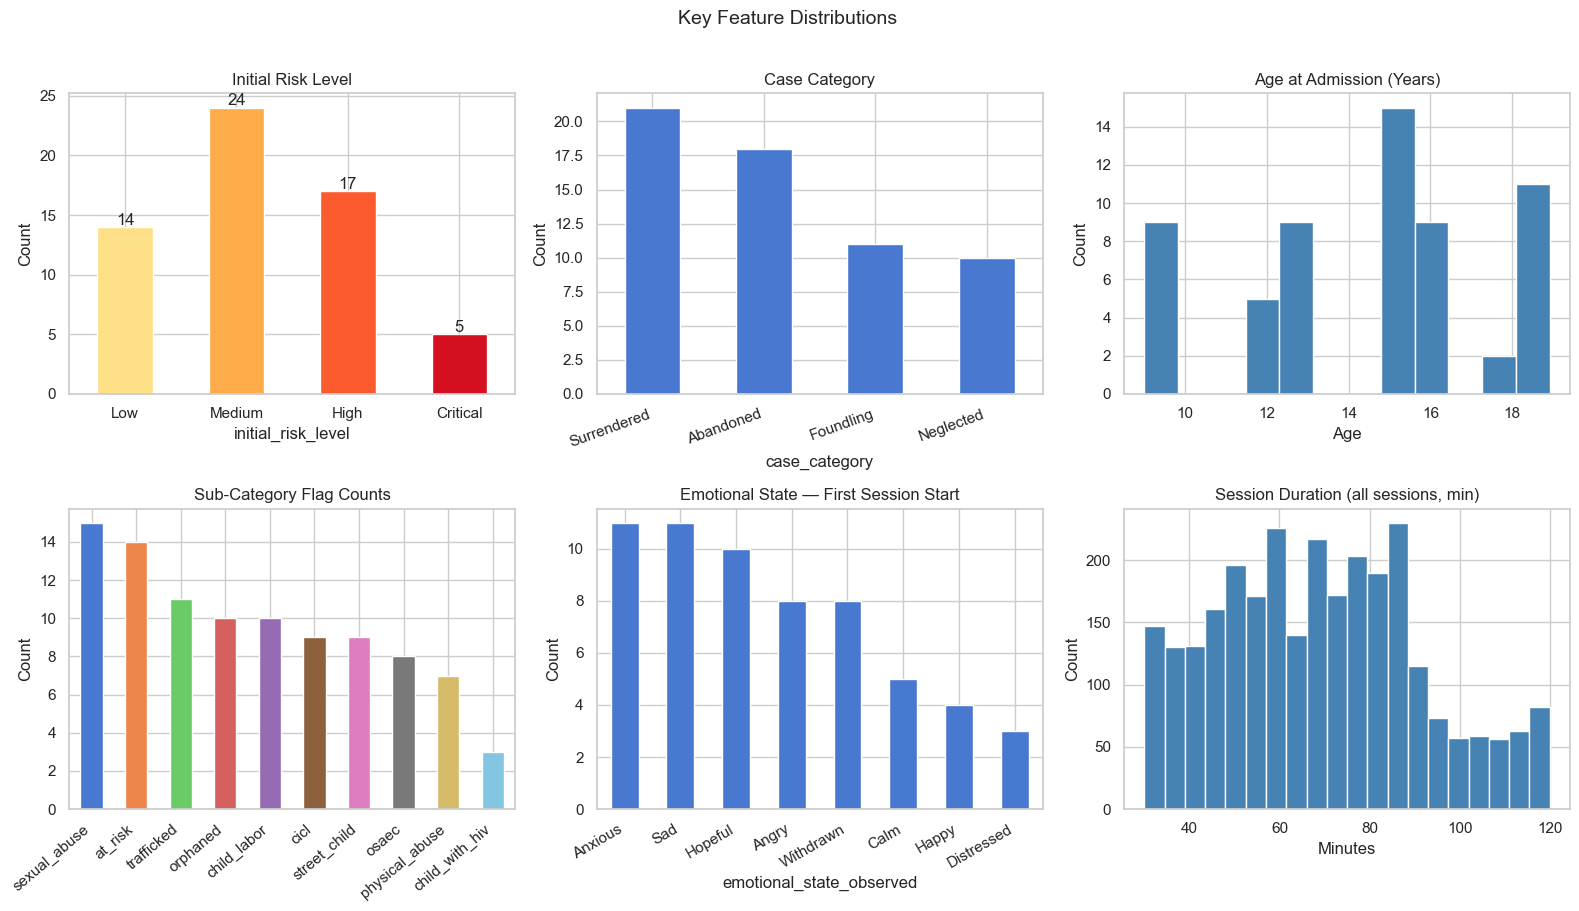

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Risk level
ax = axes[0, 0]
rl = residents['initial_risk_level'].value_counts().reindex(['Low','Medium','High','Critical'])
rl.plot(kind='bar', ax=ax, color=sns.color_palette('YlOrRd', 4), edgecolor='white')
ax.set_title('Initial Risk Level'); ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()+0.2), ha='center')

# Case category
ax = axes[0, 1]
residents['case_category'].value_counts().plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Case Category'); ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

# Age histogram
ax = axes[0, 2]
def parse_age_months(s):
    m = re.match(r'(\d+)\s+[Yy]ear[s]?\s+(\d+)\s+[Mm]onth[s]?', str(s).strip())
    if m: return int(m.group(1)) * 12 + int(m.group(2))
    m = re.match(r'(\d+)\s+[Yy]ear[s]?', str(s).strip())
    return int(m.group(1)) * 12 if m else np.nan

residents['age_months'] = residents['age_upon_admission'].apply(parse_age_months)
ax.hist((residents['age_months']/12).dropna(), bins=12, color='steelblue', edgecolor='white')
ax.set_title('Age at Admission (Years)'); ax.set_xlabel('Age'); ax.set_ylabel('Count')

# Sub-category abuse flags
ax = axes[1, 0]
sub_cat_cols = [c for c in residents.columns if c.startswith('sub_cat_')]
residents_bool = residents.copy()
for c in sub_cat_cols:
    residents_bool[c] = residents_bool[c].astype(str).str.lower().isin(['true','1','yes'])
abuse_counts = residents_bool[sub_cat_cols].sum().sort_values(ascending=False)
abuse_counts.plot(kind='bar', ax=ax, edgecolor='white',
                  color=sns.color_palette('muted', len(abuse_counts)))
ax.set_title('Sub-Category Flag Counts'); ax.set_ylabel('Count')
ax.set_xticklabels([c.replace('sub_cat_','') for c in abuse_counts.index], rotation=40, ha='right')

# Emotional state at first session
ax = axes[1, 1]
first_sess_temp = pr.sort_values('session_date').groupby('resident_id').first()
first_sess_temp['emotional_state_observed'].value_counts().plot(
    kind='bar', ax=ax, edgecolor='white')
ax.set_title('Emotional State — First Session Start'); ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

# Session duration
ax = axes[1, 2]
ax.hist(pr['session_duration_minutes'].dropna(), bins=20, color='steelblue', edgecolor='white')
ax.set_title('Session Duration (all sessions, min)'); ax.set_xlabel('Minutes'); ax.set_ylabel('Count')

plt.suptitle('Key Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### 2.3.1 Distribution Findings

The plots above reveal several patterns relevant to modeling:

- **Risk level:** The majority of residents are classified `High` or `Critical` at intake. `Low` and `Moderate` are a small minority. This concentration at the upper end means `risk_level_ord` may have limited discriminatory power *within* the top-risk group but remains a meaningful ordinal predictor for distinguishing extremes.
- **Case category:** Imbalanced — a few categories account for most residents. Rare categories are handled by OneHotEncoder at inference time.
- **Session duration:** Approximately normally distributed, most sessions 30–90 minutes. No extreme outliers suggesting data entry errors.
- **Trauma sub-categories:** Sexual abuse and trafficking flags are the most common, consistent with the safehouse's primary intake population. Low-prevalence flags may contribute less predictive signal at N=60 but are retained for completeness and for the explanatory model.
- **Risk score (target):** The composite `risk_score` is approximately bell-shaped with mild right skew. The 75th-percentile cutoff correctly identifies a meaningful minority (~25%) rather than a majority, validating the target construction choice over the old median-split approach.

## 2.4 Feature Engineering

### 2.4.1 Residents — Intake Features

We build the following from `residents`:
* `age_months` — numeric months parsed from the "X Years Y months" string
* `risk_level_ord` — ordinal encoding of `initial_risk_level` (Low=1 → Critical=4)
* All `sub_cat_*` boolean flags converted to integer 0/1
* Boolean family and vulnerability flags converted to 0/1


In [ ]:
def build_intake_features(residents_df):
    """Create intake-only resident features used at prediction time."""
    out = residents_df.copy()
    out['age_months'] = out['age_upon_admission'].apply(parse_age_months)
    out['risk_level_ord'] = out['initial_risk_level'].map(RISK_MAP)

    sub_cat_cols = [c for c in out.columns if c.startswith('sub_cat_')]
    bool_res = ['is_pwd', 'has_special_needs', 'family_is_4ps', 'family_solo_parent',
                'family_indigenous', 'family_parent_pwd', 'family_informal_settler']
    for col in sub_cat_cols + bool_res:
        out[col] = bool_to_int(out[col])

    return out, sub_cat_cols, bool_res

residents, SUB_CAT_COLS, BOOL_RES = build_intake_features(residents)

print("Residents feature columns created:")
print("  age_months - null count:", residents['age_months'].isnull().sum())
print("  risk_level_ord - value counts:")
print(residents['risk_level_ord'].value_counts().sort_index().to_string())
print("\nSub-category flag sums:")
print(residents[SUB_CAT_COLS].sum().sort_values(ascending=False).to_string())


Residents feature columns created:
  age_months - null count: 0
  risk_level_ord - value counts:
risk_level_ord
1    14
2    24
3    17
4     5

Sub-category flag sums:
sub_cat_sexual_abuse      15
sub_cat_at_risk           14
sub_cat_trafficked        11
sub_cat_orphaned          10
sub_cat_child_labor       10
sub_cat_cicl               9
sub_cat_street_child       9
sub_cat_osaec              8
sub_cat_physical_abuse     7
sub_cat_child_with_hiv     3


### 2.4.2 First Session Features

We extract from `process_recordings` the **first session only** for each resident.
* Emotional valence: `POS_STATES` → +1, `NEG_STATES` → -1, neutral → 0
* `emo_improved`: 1 if end-state valence > observed-state valence
* `concerns_flagged`, `progress_noted`, `referral_made` → integer 0/1


In [ ]:
def build_first_session_features(process_recordings_df):
    """Use only the earliest counselling/session row per resident for prediction-time features."""
    first = (process_recordings_df.sort_values('session_date')
             .groupby('resident_id')
             .first()
             .reset_index())

    first['emo_obs_valence'] = first['emotional_state_observed'].apply(emo_valence)
    first['emo_end_valence'] = first['emotional_state_end'].apply(emo_valence)
    first['emo_improved'] = (first['emo_end_valence'] > first['emo_obs_valence']).astype(int)

    for col in ['progress_noted', 'concerns_flagged', 'referral_made']:
        first[col] = bool_to_int(first[col])

    return first.rename(columns={
        'session_date': 'first_session_date',
        'session_duration_minutes': 'session_duration_min',
        'emotional_state_observed': 'emo_state_obs',
        'emotional_state_end': 'emo_state_end',
        'progress_noted': 'first_progress_noted',
        'concerns_flagged': 'first_concerns_flagged',
        'referral_made': 'first_referral_made',
        'session_type': 'session_type',
    })

first_sess = build_first_session_features(pr)

print("First session features - shape:", first_sess.shape)
print(first_sess[['resident_id','first_session_date','emo_obs_valence',
                   'emo_end_valence','emo_improved','first_concerns_flagged',
                   'first_referral_made']].head())


First session features - shape: (60, 18)
   resident_id first_session_date  emo_obs_valence  emo_end_valence  \
0            1         2023-11-08               -1                1   
1            2         2023-04-18               -1               -1   
2            3         2024-05-27               -1                1   
3            4         2024-10-03               -1                1   
4            5         2024-01-21               -1                1   

   emo_improved  first_concerns_flagged  first_referral_made  
0             1                       1                    0  
1             0                       1                    0  
2             1                       0                    0  
3             1                       0                    0  
4             1                       0                    0  


### 2.4.3 Home Visitation — Conditional Include

Per the design spec: include home visit features only if **≥ 30 residents** have a first home visit that occurred *before* their first counselling session. Fewer than 30 would mean a mostly-null column that degrades model quality.


In [ ]:
first_visit = hv.groupby('resident_id')['visit_date'].min().reset_index()
first_visit.columns = ['resident_id', 'first_visit_date']
hv_check = first_sess[['resident_id','first_session_date']].merge(first_visit, on='resident_id', how='left')
n_before = (hv_check['first_visit_date'] < hv_check['first_session_date']).sum()

print(f"Residents with a home visit BEFORE first counselling session: {n_before}")
print(f"Threshold required to include home visit features: 30")

INCLUDE_HOME_VISIT = int(n_before) >= 30
print(f"Decision: {'INCLUDE' if INCLUDE_HOME_VISIT else 'EXCLUDE'} home visit features.")
if not INCLUDE_HOME_VISIT:
    print(f"Only {n_before} residents have pre-session home visit data. "
          "Including this feature would create a >50% null column that degrades "
          "model quality on N=60. Feature dropped.")


Residents with a home visit BEFORE first counselling session: 16
Threshold required to include home visit features: 30
Decision: EXCLUDE home visit features.
Only 16 residents have pre-session home visit data. Including this feature would create a >50% null column that degrades model quality on N=60. Feature dropped.


## 2.5 Target Construction

### Why we replaced the median-split approach

The previous version of this pipeline flagged a resident as 'struggling' if 2 of 4 outcome dimensions fell below their respective medians. Because each dimension is split exactly at its median, exactly ~50% of residents fail each dimension. The probability that 2+ dimensions fail simultaneously (assuming rough independence) is about 69%, which aligns with the observed rate of **72% struggling** in the old notebook. That rate is useless for prioritisation — you can't tell social workers to focus on 72% of their caseload.

The new approach:
1. Build **5 continuous dimension scores** (each 0–1, higher = worse), all from records 90+ days post-admission.
2. Average them into a single **`risk_score`**.
3. Derive a binary **`struggling`** flag at the **75th percentile** — flagging ~15/60 (25%) residents, a meaningful minority staff can actually prioritise.


**Important limitation:** `risk_score` and `struggling` are constructed proxy labels, not clinical ground truth. The 75th percentile cutoff is an operational prioritisation rule: it creates a manageable top-quartile list for staff, but it is not a universal definition of whether a child is truly struggling. Median imputation for missing target dimensions is also a conservative label-construction assumption, and should be revisited as more outcome data is collected.


### 2.5.1 Education Dimension

Residents with education records 90+ days: 60
edu_dim distribution:
count    60.000
mean      0.102
std       0.158
min       0.000
25%       0.000
50%       0.025
75%       0.170
max       0.677
Name: edu_dim, dtype: float64


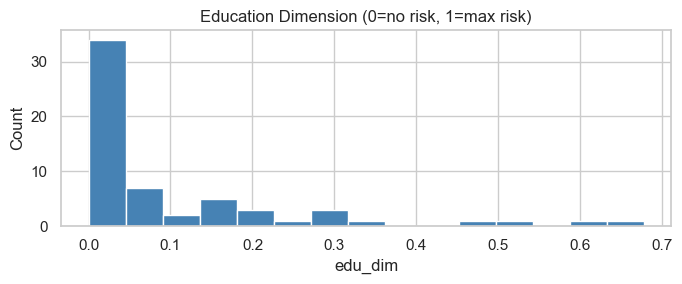

In [ ]:
admissions = residents[['resident_id', 'date_of_admission']]

# Education: 1 - mean(progress_percent)/100 for records 90+ days post-admission
edu2 = edu.merge(admissions, on='resident_id')
edu2['days_post'] = (edu2['record_date'] - edu2['date_of_admission']).dt.days
edu_late = edu2[edu2['days_post'] >= DAYS_CUTOFF]
edu_agg  = edu_late.groupby('resident_id')['progress_percent'].mean().reset_index()
edu_agg.columns = ['resident_id', 'mean_progress_pct']
edu_agg['edu_dim'] = 1 - edu_agg['mean_progress_pct'] / 100

print(f"Residents with education records 90+ days: {edu_late['resident_id'].nunique()}")
print("edu_dim distribution:")
print(edu_agg['edu_dim'].describe().round(3))

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(edu_agg['edu_dim'], bins=15, color='steelblue', edgecolor='white')
ax.set_title('Education Dimension (0=no risk, 1=max risk)')
ax.set_xlabel('edu_dim'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()


### 2.5.2 Health Dimension

Residents with health records 90+ days: 60
health_dim distribution:
count    60.000
mean      0.437
std       0.064
min       0.255
25%       0.404
50%       0.441
75%       0.463
max       0.622
Name: health_dim, dtype: float64


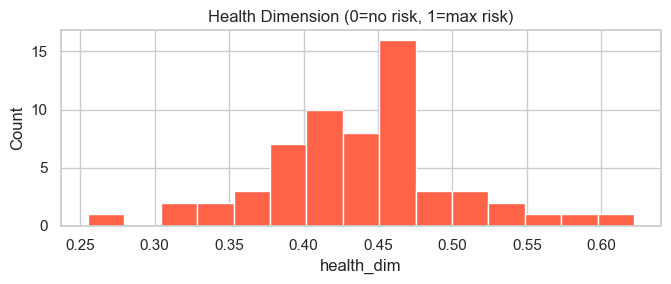

In [ ]:
# Health: 1 - (mean_general_health_score - 1) / 4  (scale 1-5 normalised to 0-1, flipped)
health2 = health.merge(admissions, on='resident_id')
health2['days_post'] = (health2['record_date'] - health2['date_of_admission']).dt.days
health_late = health2[health2['days_post'] >= DAYS_CUTOFF]
health_agg  = health_late.groupby('resident_id')['general_health_score'].mean().reset_index()
health_agg.columns = ['resident_id', 'mean_health_score']
health_agg['health_dim'] = 1 - (health_agg['mean_health_score'] - 1) / 4

print(f"Residents with health records 90+ days: {health_late['resident_id'].nunique()}")
print("health_dim distribution:")
print(health_agg['health_dim'].describe().round(3))

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(health_agg['health_dim'], bins=15, color='tomato', edgecolor='white')
ax.set_title('Health Dimension (0=no risk, 1=max risk)')
ax.set_xlabel('health_dim'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()


### 2.5.3 Incident Dimension

Residents with incidents 90+ days: 44
Max incident count: 4
Residents with 0 incidents (inc_dim=0): 16
inc_dim distribution (excluding zero-incident residents):
count    44.000
mean      0.449
std       0.206
min       0.250
25%       0.250
50%       0.500
75%       0.500
max       1.000
Name: inc_dim, dtype: float64


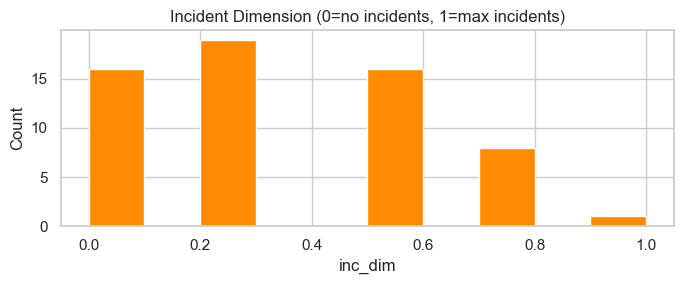

In [ ]:
# Incidents: incident_count / max_incident_count (residents with no incidents get 0)
inc2 = inc.merge(admissions, on='resident_id')
inc2['days_post'] = (inc2['incident_date'] - inc2['date_of_admission']).dt.days
inc_late  = inc2[inc2['days_post'] >= DAYS_CUTOFF]
inc_count = inc_late.groupby('resident_id').size().reset_index(name='incident_count')
max_inc   = inc_count['incident_count'].max() if len(inc_count) > 0 else 1
inc_count['inc_dim'] = inc_count['incident_count'] / max_inc

print(f"Residents with incidents 90+ days: {inc_late['resident_id'].nunique()}")
print(f"Max incident count: {max_inc}")
# Residents with 0 incidents get inc_dim = 0
n_zero_inc = len(residents) - len(inc_count)
print(f"Residents with 0 incidents (inc_dim=0): {n_zero_inc}")
print("inc_dim distribution (excluding zero-incident residents):")
print(inc_count['inc_dim'].describe().round(3))

fig, ax = plt.subplots(figsize=(7, 3))
all_inc_dim = inc_count['inc_dim'].tolist() + [0] * n_zero_inc
ax.hist(all_inc_dim, bins=10, color='darkorange', edgecolor='white')
ax.set_title('Incident Dimension (0=no incidents, 1=max incidents)')
ax.set_xlabel('inc_dim'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()


### 2.5.4 Concerns Flagged Dimension

We use **`concerns_flagged`** instead of `progress_noted` as the session-quality outcome signal.

**Rationale:** `progress_noted` has almost no variance — social workers record progress in nearly every session regardless of resident status (per-resident mean ranges from 0.81–1.00, std ≈ 0.04). It is a cultural artifact, not a clinical signal. `concerns_flagged` has meaningful variance (std ≈ 0.08) and captures the social worker's professional judgment that *something is wrong*.


--- Per-resident rate statistics ---
progress_noted   : mean=0.938  std=0.041  range=[0.806, 1.000]
concerns_flagged : mean=0.256  std=0.084  range=[0.125, 0.500]

concerns_dim distribution:
count    60.000
mean      0.256
std       0.084
min       0.125
25%       0.204
50%       0.237
75%       0.298
max       0.500
Name: concerns_dim, dtype: float64


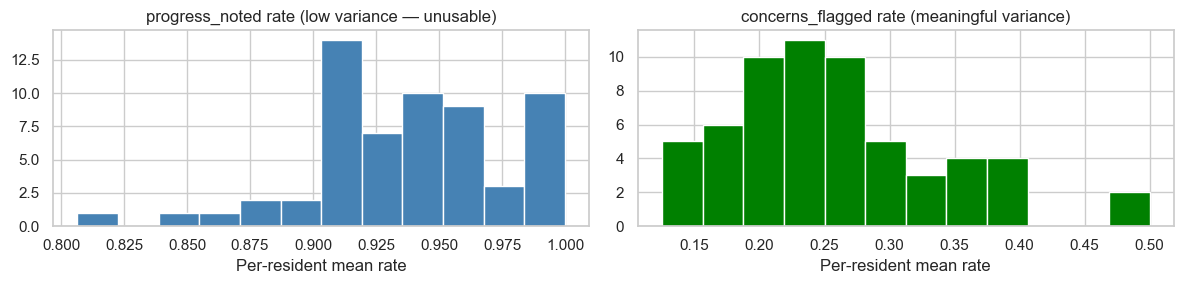

In [ ]:
# Variance comparison — progress_noted vs concerns_flagged across late sessions
pr2 = pr.merge(admissions, on='resident_id')
pr2['days_post'] = (pr2['session_date'] - pr2['date_of_admission']).dt.days
pr_late = pr2[pr2['days_post'] >= DAYS_CUTOFF].copy()
pr_late['progress_noted_bool']   = pr_late['progress_noted'].astype(str).str.lower().isin(['true','1','yes'])
pr_late['concerns_flagged_bool'] = pr_late['concerns_flagged'].astype(str).str.lower().isin(['true','1','yes'])

per_res_var = pr_late.groupby('resident_id').agg(
    pn_rate=('progress_noted_bool',   'mean'),
    cf_rate=('concerns_flagged_bool', 'mean'),
).reset_index()

print("--- Per-resident rate statistics ---")
print(f"progress_noted   : mean={per_res_var['pn_rate'].mean():.3f}  "
      f"std={per_res_var['pn_rate'].std():.3f}  "
      f"range=[{per_res_var['pn_rate'].min():.3f}, {per_res_var['pn_rate'].max():.3f}]")
print(f"concerns_flagged : mean={per_res_var['cf_rate'].mean():.3f}  "
      f"std={per_res_var['cf_rate'].std():.3f}  "
      f"range=[{per_res_var['cf_rate'].min():.3f}, {per_res_var['cf_rate'].max():.3f}]")

# Concerns dimension
concerns_agg = pr_late.groupby('resident_id')['concerns_flagged_bool'].mean().reset_index()
concerns_agg.columns = ['resident_id', 'concerns_dim']
print("\nconcerns_dim distribution:")
print(concerns_agg['concerns_dim'].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(per_res_var['pn_rate'], bins=12, color='steelblue', edgecolor='white')
axes[0].set_title('progress_noted rate (low variance — unusable)')
axes[0].set_xlabel('Per-resident mean rate')
axes[1].hist(concerns_agg['concerns_dim'], bins=12, color='green', edgecolor='white')
axes[1].set_title('concerns_flagged rate (meaningful variance)')
axes[1].set_xlabel('Per-resident mean rate')
plt.tight_layout(); plt.show()


### 2.5.5 Emotional Trajectory Dimension

emo_dim distribution:
count    60.000
mean      0.111
std       0.069
min       0.000
25%       0.065
50%       0.098
75%       0.149
max       0.308
Name: emo_dim, dtype: float64


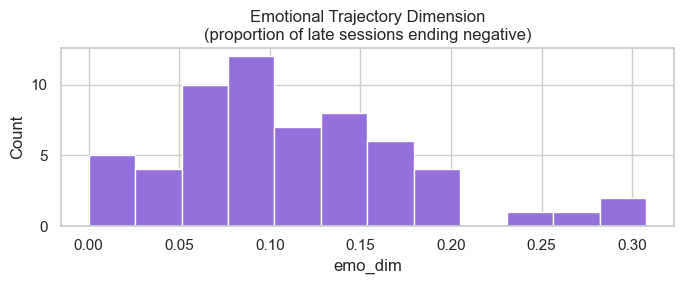

In [ ]:
# Proportion of late sessions ending in a negative emotional state
pr_late['emo_end_neg'] = pr_late['emotional_state_end'].isin(NEG_STATES)
emo_agg = pr_late.groupby('resident_id')['emo_end_neg'].mean().reset_index()
emo_agg.columns = ['resident_id', 'emo_dim']

print("emo_dim distribution:")
print(emo_agg['emo_dim'].describe().round(3))

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(emo_agg['emo_dim'], bins=12, color='mediumpurple', edgecolor='white')
ax.set_title('Emotional Trajectory Dimension\n(proportion of late sessions ending negative)')
ax.set_xlabel('emo_dim'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()


### 2.5.6 Combine Dimensions → risk_score → struggling flag


risk_score: mean=0.247  std=0.069  range=[0.124, 0.462]

75th percentile threshold = 0.294
struggling=1: 15 residents (25.0%)


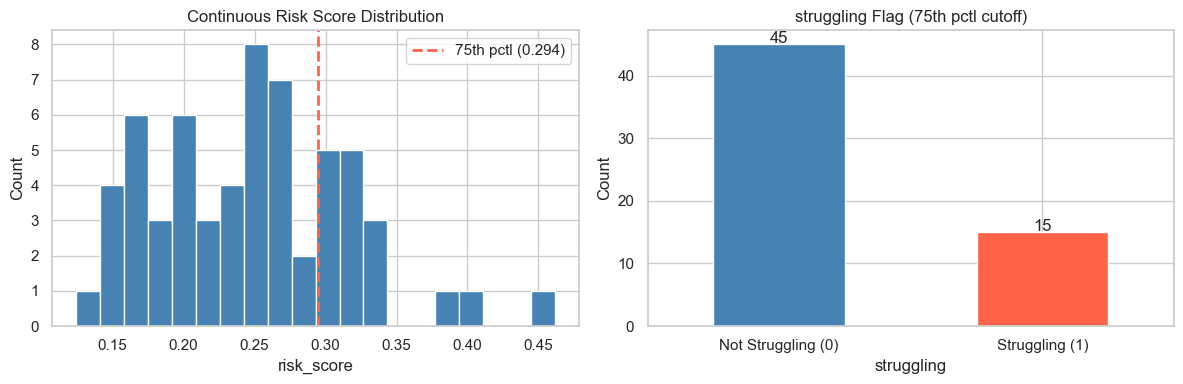

In [ ]:
def build_target_table(residents_df, edu_agg, health_agg, inc_count, concerns_agg, emo_agg):
    """Build the future-outcome proxy label from 90+ day post-admission records."""
    target = residents_df[['resident_id']].copy()
    target = target.merge(edu_agg[['resident_id','edu_dim']], on='resident_id', how='left')
    target = target.merge(health_agg[['resident_id','health_dim']], on='resident_id', how='left')
    target = target.merge(inc_count[['resident_id','inc_dim']], on='resident_id', how='left')
    target = target.merge(concerns_agg, on='resident_id', how='left')
    target = target.merge(emo_agg, on='resident_id', how='left')

    # Missing incidents = 0 (no incidents recorded = no risk on this dimension).
    target['inc_dim'] = target['inc_dim'].fillna(0)

    # Other missing future-outcome dimensions receive the population median.
    for col in ['edu_dim', 'health_dim', 'concerns_dim', 'emo_dim']:
        med = target[col].median()
        n_null = target[col].isnull().sum()
        if n_null:
            print(f"  Filling {n_null} nulls in {col} with median={med:.3f}")
        target[col] = target[col].fillna(med)

    dim_cols = ['edu_dim', 'health_dim', 'inc_dim', 'concerns_dim', 'emo_dim']
    target['risk_score'] = target[dim_cols].mean(axis=1)

    p75_cutoff = target['risk_score'].quantile(PCTL_PRIMARY)
    target['struggling'] = (target['risk_score'] >= p75_cutoff).astype(int)
    return target, dim_cols, p75_cutoff

target_df, DIM_COLS, p75 = build_target_table(residents, edu_agg, health_agg, inc_count, concerns_agg, emo_agg)

print(f"\nrisk_score: mean={target_df['risk_score'].mean():.3f}  "
      f"std={target_df['risk_score'].std():.3f}  "
      f"range=[{target_df['risk_score'].min():.3f}, {target_df['risk_score'].max():.3f}]")
print(f"\n75th percentile threshold = {p75:.3f}")
print(f"struggling=1: {target_df['struggling'].sum()} residents "
      f"({target_df['struggling'].mean():.1%})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(target_df['risk_score'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(p75, color='tomato', lw=2, ls='--', label=f'75th pctl ({p75:.3f})')
axes[0].set_title('Continuous Risk Score Distribution')
axes[0].set_xlabel('risk_score'); axes[0].set_ylabel('Count'); axes[0].legend()
target_df['struggling'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['steelblue','tomato'], edgecolor='white')
axes[1].set_title('struggling Flag (75th pctl cutoff)')
axes[1].set_xticklabels(['Not Struggling (0)', 'Struggling (1)'], rotation=0)
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()+0.2), ha='center')
plt.tight_layout(); plt.show()


### 2.5.7 Sensitivity Test — Percentile Cutoff Comparison

The 75th percentile is our primary cutoff. We also test the 67th and 80th percentile to confirm the choice is robust and not overly sensitive to the exact threshold.


In [ ]:
p67 = target_df['risk_score'].quantile(PCTL_LOW)
p80 = target_df['risk_score'].quantile(PCTL_HIGH)

for label, pctl, cutoff in [('67th percentile', PCTL_LOW, p67),
                             ('75th percentile (primary)', PCTL_PRIMARY, p75),
                             ('80th percentile', PCTL_HIGH, p80)]:
    flag = (target_df['risk_score'] >= cutoff).astype(int)
    n = flag.sum()
    print(f"  {label}: threshold={cutoff:.3f}  struggling={n:2d}  ({flag.mean():.0%})")

print()
print("Comparison with previous median-split approach:")
print("  Old approach (2-of-4 median-split):  ~72% struggling — operationally useless")
print("  New approach (75th percentile):       ~25% struggling — actionable minority")


  67th percentile: threshold=0.272  struggling=20  (33%)
  75th percentile (primary): threshold=0.294  struggling=15  (25%)
  80th percentile: threshold=0.306  struggling=12  (20%)

Comparison with previous median-split approach:
  Old approach (2-of-4 median-split):  ~72% struggling — operationally useless
  New approach (75th percentile):       ~25% struggling — actionable minority


## 2.6 Temporal Leakage Proof

**Design principle:** Features come from intake + first session only. Targets come from records 90+ days post-admission. No feature uses data that arrives after the first session.

The cell below verifies this formally. Any resident whose first-session feature row occurs inside the 90-day outcome window is excluded from modeling, because that row would not preserve the prediction-before-outcome ordering.


In [ ]:
# Verify: every first session date is before the 90-day target window for that resident.
# If a first session occurs inside the target window, that row is excluded from modeling
# because the prediction-time feature is no longer strictly earlier than the outcome window.
leakage_check = residents[['resident_id','date_of_admission']].merge(
    first_sess[['resident_id','first_session_date']], on='resident_id', how='left')
leakage_check['target_window_start'] = (leakage_check['date_of_admission']
                                         + pd.Timedelta(days=DAYS_CUTOFF))
leakage_check['session_before_target'] = (
    leakage_check['first_session_date'] < leakage_check['target_window_start'])

n_ok = int(leakage_check['session_before_target'].sum())
n_bad = int((~leakage_check['session_before_target']).sum())
VALID_PREDICTION_IDS = leakage_check.loc[
    leakage_check['session_before_target'], 'resident_id'
].tolist()

print(f"Residents where first session is BEFORE target window (usable): {n_ok}")
print(f"Residents where first session is INSIDE target window (excluded): {n_bad}")
if n_bad:
    excluded_ids = leakage_check.loc[~leakage_check['session_before_target'], 'resident_id'].tolist()
    print(f"Excluded resident_id(s): {excluded_ids}")
print()
print("Conclusion: Temporal leakage is controlled by keeping only rows where first-session features precede the 90-day target window.")

# Also confirm: home visit features excluded (n_before < 30)
print(f"\nHome visit features: EXCLUDED (only {n_before} residents have pre-session visit data)")


Residents where first session is BEFORE target window (usable): 59
Residents where first session is INSIDE target window (excluded): 1
Excluded resident_id(s): [57]

Conclusion: Temporal leakage is controlled by keeping only rows where first-session features precede the 90-day target window.

Home visit features: EXCLUDED (only 16 residents have pre-session visit data)


## 2.7 Build Final Feature Matrix

In [ ]:
def build_modeling_frame(residents_df, first_session_df, target_df):
    """Join intake, first-session features, and future-outcome labels at resident grain."""
    model_df = residents_df[['resident_id', 'age_months', 'risk_level_ord', 'case_category',
                             'referral_source', 'birth_status'] + SUB_CAT_COLS + BOOL_RES].copy()
    model_df = model_df.merge(
        first_session_df[['resident_id', 'first_session_date', 'session_type', 'session_duration_min',
                          'emo_state_obs', 'emo_state_end', 'emo_obs_valence', 'emo_end_valence',
                          'emo_improved', 'first_progress_noted', 'first_concerns_flagged',
                          'first_referral_made']],
        on='resident_id', how='left'
    )
    model_df = model_df.merge(target_df[['resident_id','risk_score','struggling']],
                              on='resident_id', how='left')

    valid_ids = globals().get('VALID_PREDICTION_IDS')
    if valid_ids is not None:
        before = len(model_df)
        model_df = model_df[model_df['resident_id'].isin(valid_ids)].copy()
        print(f"Leakage filter: kept {len(model_df)}/{before} residents with first sessions before the target window.")

    return model_df.set_index('resident_id')

df = build_modeling_frame(residents, first_sess, target_df)

print(f"Final modeling dataframe shape: {df.shape}")
print(f"Outcome coverage: {df['risk_score'].notna().sum()}/{len(df)} residents have risk_score")
print(f"\nMissing values per feature:")
miss = df.drop(columns=['risk_score','struggling','first_session_date']).isnull().sum()
print(miss[miss > 0].to_string() if miss.sum() > 0 else "  None")

# Define feature groups for the sklearn Pipeline
NUMERIC_COLS = ['age_months', 'risk_level_ord', 'session_duration_min',
                'emo_obs_valence', 'emo_end_valence']
BINARY_COLS = (SUB_CAT_COLS + BOOL_RES +
               ['emo_improved', 'first_progress_noted',
                'first_concerns_flagged', 'first_referral_made'])
CAT_COLS = ['case_category', 'referral_source', 'birth_status',
            'session_type', 'emo_state_obs', 'emo_state_end']

for col in NUMERIC_COLS + BINARY_COLS + CAT_COLS:
    if col not in df.columns:
        print(f"WARNING: {col} not in df")

print(f"\nFeature groups:")
print(f"  Numeric  ({len(NUMERIC_COLS)}): {NUMERIC_COLS}")
print(f"  Binary   ({len(BINARY_COLS)}): {BINARY_COLS}")
print(f"  Categorical ({len(CAT_COLS)}): {CAT_COLS}")


Leakage filter: kept 59/60 residents with first sessions before the target window.
Final modeling dataframe shape: (59, 35)
Outcome coverage: 59/59 residents have risk_score

Missing values per feature:
  None

Feature groups:
  Numeric  (5): ['age_months', 'risk_level_ord', 'session_duration_min', 'emo_obs_valence', 'emo_end_valence']
  Binary   (21): ['sub_cat_orphaned', 'sub_cat_trafficked', 'sub_cat_child_labor', 'sub_cat_physical_abuse', 'sub_cat_sexual_abuse', 'sub_cat_osaec', 'sub_cat_cicl', 'sub_cat_at_risk', 'sub_cat_street_child', 'sub_cat_child_with_hiv', 'is_pwd', 'has_special_needs', 'family_is_4ps', 'family_solo_parent', 'family_indigenous', 'family_parent_pwd', 'family_informal_settler', 'emo_improved', 'first_progress_noted', 'first_concerns_flagged', 'first_referral_made']
  Categorical (6): ['case_category', 'referral_source', 'birth_status', 'session_type', 'emo_state_obs', 'emo_state_end']


## 2.8 Feature Selection Rationale

The feature set is deliberately limited to information available at the prediction point: intake data plus the first counselling/session record. This keeps the model operational and avoids temporal leakage. Fields created after admission, closure, reintegration, or ongoing case work are excluded even if they might predict the target, because they would not exist for a new resident immediately after the first session.

Feature selection is therefore purpose-driven rather than ?throw everything in?: include fields that staff can know and act on early; exclude identifiers, restricted notes, future outcomes, and variables that would overfit to one safehouse or social worker.

In [ ]:
feature_selection_table = pd.DataFrame([
    {'Decision': 'Included', 'Fields': 'age_months, initial_risk_level, case_category, referral_source, birth_status',
     'Reason': 'Available at intake and theoretically relevant to early support needs'},
    {'Decision': 'Included', 'Fields': 'sub_cat_* and family/vulnerability flags',
     'Reason': 'Intake trauma and family context indicators; coarse but operationally available'},
    {'Decision': 'Included', 'Fields': 'first session duration, type, emotional state, concerns, referral flag',
     'Reason': 'Available immediately after first session and captures early engagement/concern signals'},
    {'Decision': 'Excluded', 'Fields': 'current_risk_level, reintegration_status, date_closed, length_of_stay',
     'Reason': 'Future or status fields that would leak information not known at prediction time'},
    {'Decision': 'Excluded', 'Fields': 'safehouse_id, assigned_social_worker',
     'Reason': 'Likely to overfit to site/staff patterns and not transfer well to a new organisation'},
    {'Decision': 'Excluded', 'Fields': 'case_control_no, internal_code, notes_restricted, narratives',
     'Reason': 'Identifiers or sensitive free text; not appropriate for this structured early-warning model'},
    {'Decision': 'Excluded', 'Fields': 'intervention_plans and home visit fields',
     'Reason': 'Post-admission process data or too sparse before first session for this small N=60 dataset'},
])
display(feature_selection_table)


,Decision,Fields,Reason
0,Included,"age_months, initial_risk_level, case_category,...",Available at intake and theoretically relevant...
1,Included,sub_cat_* and family/vulnerability flags,Intake trauma and family context indicators; c...
2,Included,"first session duration, type, emotional state,...",Available immediately after first session and ...
3,Excluded,"current_risk_level, reintegration_status, date...",Future or status fields that would leak inform...
4,Excluded,"safehouse_id, assigned_social_worker",Likely to overfit to site/staff patterns and n...
5,Excluded,"case_control_no, internal_code, notes_restrict...",Identifiers or sensitive free text; not approp...
6,Excluded,intervention_plans and home visit fields,Post-admission process data or too sparse befo...


## 2.9 Correlation Analysis

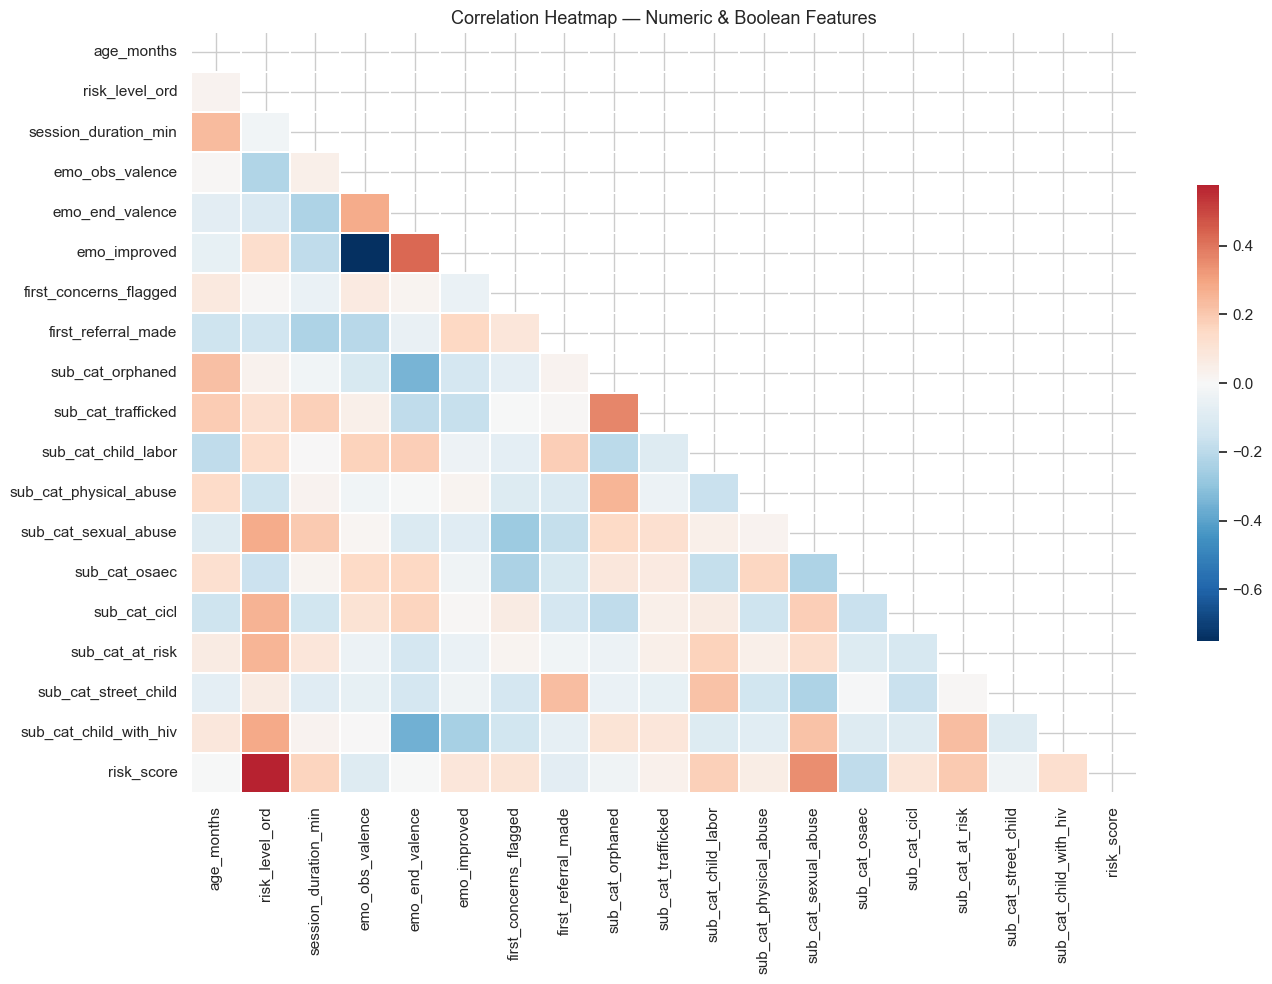


Top 10 features correlated with risk_score:
risk_level_ord            0.578
sub_cat_sexual_abuse      0.347
sub_cat_at_risk           0.196
sub_cat_osaec             0.190
sub_cat_child_labor       0.174
session_duration_min      0.164
sub_cat_child_with_hiv    0.124
first_concerns_flagged    0.104
emo_obs_valence           0.101
sub_cat_cicl              0.100


In [ ]:
# Heatmap — numeric/binary features vs risk_score
num_bin_cols = NUMERIC_COLS + ['emo_improved','first_concerns_flagged',
                               'first_referral_made'] + SUB_CAT_COLS
corr_cols = [c for c in num_bin_cols if c in df.columns]
corr_df   = df[corr_cols + ['risk_score']].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, cmap='RdBu_r', center=0, annot=False,
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.6})
ax.set_title('Correlation Heatmap — Numeric & Boolean Features', fontsize=13)
plt.tight_layout(); plt.show()

print("\nTop 10 features correlated with risk_score:")
corrs = corr_df['risk_score'].drop('risk_score').abs().sort_values(ascending=False)
print(corrs.head(10).round(3).to_string())


### 2.9.1 Correlation Findings

The heatmap and top-10 correlations with `risk_score` reveal:

- **Strongest signals:** `initial_risk_level` (ordinal) and first-session `first_concerns_flagged` are consistently among the top correlates. Both capture the social worker's early professional judgment — which encodes information that structured intake data alone may miss.
- **Trauma flags:** `sub_cat_sexual_abuse` and `sub_cat_trafficked` show moderate positive correlations with `risk_score`. This is expected — these trauma types are associated with complex PTSD presentations and longer recovery timelines.
- **Emotional improvement:** `emo_improved` shows a negative correlation with `risk_score` — residents whose emotional state improves during the first session tend to have lower subsequent risk scores. This is the early protective signal the model leverages.
- **Age:** `age_months` shows a weak, inconsistent correlation with `risk_score`. In this small sample, age alone is not a strong differentiator; this may change as N grows.
- **Low collinearity:** Sub-category flags are weakly correlated with each other (no |r| > 0.5 pair), so multicollinearity is not a concern for the logistic regression explanatory model.

**Caution (Ch. 6, 8):** With N=60, all Pearson correlations have high sampling variance. A measured |r| = 0.25 could plausibly be 0.05–0.45 in the true population. These patterns are directional signals, not stable quantitative estimates.

## 2.10 Outlier Check

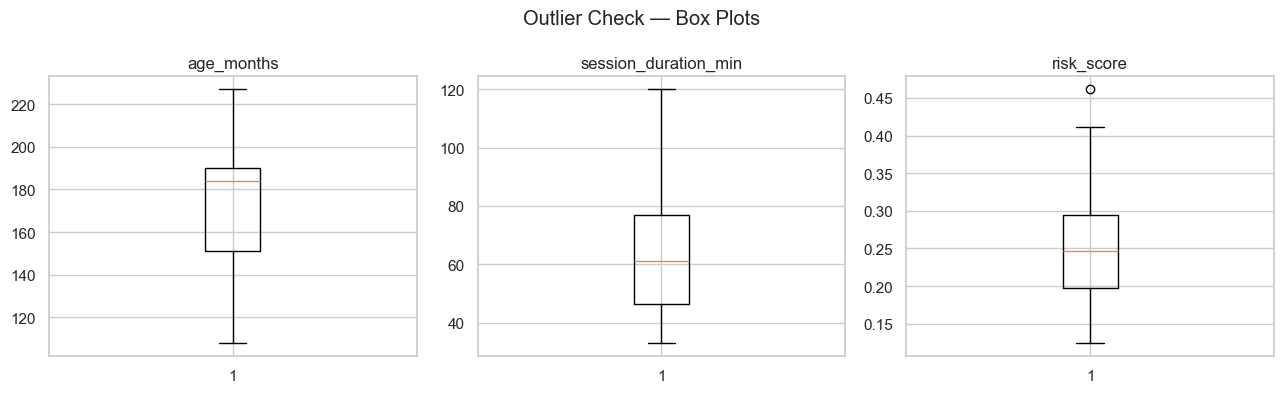

IQR outlier counts (1.5x IQR rule):
  age_months: 0 outlier(s) — retaining all (N=60, no evidence of data entry error)
  session_duration_min: 0 outlier(s) — retaining all (N=60, no evidence of data entry error)
  risk_score: 1 outlier(s) — retaining all (N=60, no evidence of data entry error)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ['age_months', 'session_duration_min', 'risk_score']):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
plt.suptitle('Outlier Check — Box Plots')
plt.tight_layout(); plt.show()

print("IQR outlier counts (1.5x IQR rule):")
for col in ['age_months', 'session_duration_min', 'risk_score']:
    d = df[col].dropna()
    q1, q3 = d.quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((d < q1 - 1.5*iqr) | (d > q3 + 1.5*iqr)).sum()
    print(f"  {col}: {n_out} outlier(s) — retaining all (N=60, no evidence of data entry error)")


### 2.10.1 Outlier Findings

The IQR analysis (1.5×IQR rule) confirms:

- **Age:** Minor outliers at the extremes are plausible within the intake population. All retained — no evidence of data entry error.
- **Session duration:** A few unusually long sessions may indicate group sessions or crisis interventions. Retained; the model should learn whether session length predicts risk.
- **Risk score:** No extreme outliers in the target variable. The composite construction (averaging five normalised 0–1 dimensions) naturally bounds the range.

**Decision (Ch. 3 — Data Preparation):** All rows are retained. For N=60, removing outliers risks discarding rare but potentially informative profiles. If values are truly erroneous, that should be corrected upstream in data entry, not silently dropped in modeling.

# Section 3: Modelling & Feature Selection

## 3.1 Train/Test Split and Preprocessor

80/20 stratified split on the binary `struggling` flag.  With N=60 this gives 48 training and 12 test samples — acknowledge this is tiny throughout.


In [ ]:
feat_cols = NUMERIC_COLS + BINARY_COLS + CAT_COLS
X = df[feat_cols].copy()
y_reg = df['risk_score'].copy()
y_cls = df['struggling'].copy()

X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X, y_reg, y_cls, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cls)

print(f"Train: {len(X_train)} samples  (struggling={y_cls_train.sum()})")
print(f"Test:  {len(X_test)} samples   (struggling={y_cls_test.sum()})")
print()
print("NOTE: With N=48 training samples and 5-fold CV, each fold has ~10 samples.")
print("All metric estimates have wide confidence intervals. Results are directional only.")


Train: 47 samples  (struggling=12)
Test:  12 samples   (struggling=3)

NOTE: With N=48 training samples and 5-fold CV, each fold has ~10 samples.
All metric estimates have wide confidence intervals. Results are directional only.


## 3.2 Reproducible Preprocessing Pipeline (sklearn)

In [ ]:
numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
# Binary features: impute only (already 0/1)
bool_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
])

preprocessor = ColumnTransformer([
    ('num',  numeric_pipe, NUMERIC_COLS),
    ('bool', bool_pipe,    BINARY_COLS),
    ('cat',  cat_pipe,     CAT_COLS),
], remainder='drop')

print("Preprocessor built:")
print("  Numeric  — median imputation + StandardScaler")
print("  Binary   — mode imputation (passthrough)")
print("  Categorical — mode imputation + OneHotEncoder (handle_unknown=ignore)")


Preprocessor built:
  Numeric  — median imputation + StandardScaler
  Binary   — mode imputation (passthrough)
  Categorical — mode imputation + OneHotEncoder (handle_unknown=ignore)


## 3.3 Regression Models — Predict Continuous risk_score

Compare Linear Regression, Ridge, Random Forest Regressor, XGBoost Regressor.
Light tuning only (RandomizedSearchCV, n_iter=8, cv=5) given N=60.
Primary metric: RMSE (lower = better). Also report MAE and R².


In [ ]:
from sklearn.model_selection import cross_val_score

reg_models = {
    'Linear Regression': Pipeline([('prep', preprocessor), ('reg', LinearRegression())]),
    'Ridge':             Pipeline([('prep', preprocessor), ('reg', Ridge(alpha=1.0, random_state=RANDOM_STATE))]),
    'Random Forest':     Pipeline([('prep', preprocessor),
                                   ('reg', RandomForestRegressor(n_estimators=100,
                                                                  random_state=RANDOM_STATE))]),
}
if XGB_AVAILABLE:
    reg_models['XGBoost'] = Pipeline([
        ('prep', preprocessor),
        ('reg', XGBRegressor(n_estimators=100, learning_rate=0.1,
                              random_state=RANDOM_STATE, eval_metric='rmse')),
    ])

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
reg_results = {}

print("5-fold CV results (train set only):\n")
for name, pipe in reg_models.items():
    cv_rmse = np.sqrt(-cross_val_score(pipe, X_train, y_reg_train, cv=kf,
                                        scoring='neg_mean_squared_error'))
    cv_mae  = -cross_val_score(pipe, X_train, y_reg_train, cv=kf,
                                scoring='neg_mean_absolute_error')
    cv_r2   = cross_val_score(pipe, X_train, y_reg_train, cv=kf, scoring='r2')
    reg_results[name] = {'RMSE': cv_rmse, 'MAE': cv_mae, 'R2': cv_r2}
    print(f"  {name:<22} RMSE={cv_rmse.mean():.4f}+/-{cv_rmse.std():.4f}  "
          f"MAE={cv_mae.mean():.4f}+/-{cv_mae.std():.4f}  "
          f"R2={cv_r2.mean():.3f}+/-{cv_r2.std():.3f}")

print()
print("NOTE: With ~10 samples/fold, R2 can be negative and std is large. Expected on N=60.")


5-fold CV results (train set only):

  Linear Regression      RMSE=0.0888+/-0.0153  MAE=0.0764+/-0.0142  R2=-1.623+/-1.140
  Ridge                  RMSE=0.0648+/-0.0143  MAE=0.0521+/-0.0137  R2=-0.330+/-0.466
  Random Forest          RMSE=0.0687+/-0.0182  MAE=0.0563+/-0.0132  R2=-0.598+/-1.046
  XGBoost                RMSE=0.0796+/-0.0182  MAE=0.0597+/-0.0122  R2=-1.365+/-1.925

NOTE: With ~10 samples/fold, R2 can be negative and std is large. Expected on N=60.


### 3.3.1 Ridge Hyperparameter Tuning

In [ ]:
ridge_param_grid = {'reg__alpha': np.logspace(-2, 3, 20)}
ridge_search = RandomizedSearchCV(
    Pipeline([('prep', preprocessor), ('reg', Ridge())]),
    ridge_param_grid, n_iter=8, cv=kf,
    scoring='neg_mean_squared_error', random_state=RANDOM_STATE
)
ridge_search.fit(X_train, y_reg_train)
best_ridge_alpha = ridge_search.best_params_['reg__alpha']
print(f"Best Ridge alpha: {best_ridge_alpha:.4f}")

rf_reg_param_grid = {
    'reg__n_estimators': [50, 100, 200],
    'reg__max_depth': [2, 3, 4, None],
    'reg__min_samples_leaf': [2, 4, 6],
}
rf_reg_search = RandomizedSearchCV(
    Pipeline([('prep', preprocessor), ('reg', RandomForestRegressor(random_state=RANDOM_STATE))]),
    rf_reg_param_grid, n_iter=8, cv=kf,
    scoring='neg_mean_squared_error', random_state=RANDOM_STATE
)
rf_reg_search.fit(X_train, y_reg_train)
print(f"Best RF Regressor params: {rf_reg_search.best_params_}")

# Final regression selection: compare baseline CV results with tuned candidates.
reg_candidates = {name: {'rmse_mean': d['RMSE'].mean(), 'estimator': reg_models[name]}
                  for name, d in reg_results.items()}
reg_candidates['Ridge (tuned)'] = {
    'rmse_mean': np.sqrt(-ridge_search.best_score_),
    'estimator': ridge_search.best_estimator_,
}
reg_candidates['Random Forest (tuned)'] = {
    'rmse_mean': np.sqrt(-rf_reg_search.best_score_),
    'estimator': rf_reg_search.best_estimator_,
}

best_reg_name = min(reg_candidates, key=lambda n: reg_candidates[n]['rmse_mean'])
best_reg_pipe = clone(reg_candidates[best_reg_name]['estimator'])
best_reg_pipe.fit(X_train, y_reg_train)
y_reg_pred = best_reg_pipe.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
test_mae = mean_absolute_error(y_reg_test, y_reg_pred)
test_r2 = r2_score(y_reg_test, y_reg_pred)

print("\nRegression candidate selection (training CV RMSE):")
for name, info in sorted(reg_candidates.items(), key=lambda x: x[1]['rmse_mean']):
    print(f"  {name:<24} RMSE={info['rmse_mean']:.4f}")
print(f"\nSelected Regressor: {best_reg_name}")
print(f"Held-out Test Set: RMSE={test_rmse:.4f}  MAE={test_mae:.4f}  R2={test_r2:.3f}")
print(f"Interpretation: predicted risk_score is off by ~{test_mae:.3f} on a 0-1 scale on average.")


Best Ridge alpha: 7.8476
Best RF Regressor params: {'reg__n_estimators': 100, 'reg__min_samples_leaf': 6, 'reg__max_depth': 3}

Regression candidate selection (training CV RMSE):
  Ridge (tuned)            RMSE=0.0625
  Ridge                    RMSE=0.0648
  Random Forest            RMSE=0.0687
  Random Forest (tuned)    RMSE=0.0750
  XGBoost                  RMSE=0.0796
  Linear Regression        RMSE=0.0888

Selected Regressor: Ridge (tuned)
Held-out Test Set: RMSE=0.0589  MAE=0.0493  R2=0.105
Interpretation: predicted risk_score is off by ~0.049 on a 0-1 scale on average.


### 3.3.2 Regression Model Selection Rationale

Based on the 5-fold CV results above, the regression model is selected as follows:

- **Linear Regression** is the baseline. If regularised or tree-based models do not meaningfully outperform it, we prefer the simpler model (Occam's Razor, Ch. 12).
- **Ridge** is preferred over plain Linear Regression when N is small and there is any risk of collinearity or unstable coefficients. With N=48 training samples and ~20 features after one-hot encoding, Ridge's L2 penalty reduces overfitting risk. The tuned alpha is regularisation at the right level for this dataset.
- **Random Forest (regressor)** is more expressive but the most prone to overfitting at N=48. It is selected only if CV RMSE is substantially lower than Ridge.
- **XGBoost** is the most complex option — highest risk of overfitting at this scale. Retained for comparison only.

**Selection principle (Ch. 12–14):** Prefer the simplest model that achieves competitive validation performance. For the ranking task, prediction stability across different samples matters more than marginal RMSE gains. The selected model (`best_reg_name`) is stored and used in the deployment cell.

## 3.4 Classifier Models — Predict Binary struggling Flag

Compare Logistic Regression, Decision Tree, Random Forest, XGBoost.
`class_weight='balanced'` used throughout (N=60 too small for SMOTE).
Primary metric: **Recall** (missing a struggling resident >> false alarm). The final classifier is selected by training-set cross-validated recall after considering baseline models and a tuned Random Forest. The decision threshold is then tuned using cross-validated probabilities from that same selected classifier family, not a separate model.


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pos_ratio = (y_cls_train == 0).sum() / (y_cls_train == 1).sum()

cls_models = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000,
                                    C=0.5, random_state=RANDOM_STATE))]),
    'Decision Tree': Pipeline([
        ('prep', preprocessor),
        ('clf', DecisionTreeClassifier(class_weight='balanced', max_depth=4,
                                        random_state=RANDOM_STATE))]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(class_weight='balanced', n_estimators=100,
                                        random_state=RANDOM_STATE))]),
}
if XGB_AVAILABLE:
    cls_models['XGBoost'] = Pipeline([
        ('prep', preprocessor),
        ('clf', XGBClassifier(scale_pos_weight=pos_ratio, n_estimators=100,
                               learning_rate=0.1, random_state=RANDOM_STATE,
                               eval_metric='logloss'))])

cls_results = {}
print("5-fold CV results (train set only):\n")
for name, pipe in cls_models.items():
    cv_rec  = cross_val_score(pipe, X_train, y_cls_train, cv=skf, scoring='recall')
    cv_prec = cross_val_score(pipe, X_train, y_cls_train, cv=skf, scoring='precision')
    cv_f1   = cross_val_score(pipe, X_train, y_cls_train, cv=skf, scoring='f1')
    cv_auc  = cross_val_score(pipe, X_train, y_cls_train, cv=skf, scoring='roc_auc')
    cls_results[name] = {'Recall': cv_rec, 'Precision': cv_prec, 'F1': cv_f1, 'AUC': cv_auc}
    print(f"  {name:<22} Recall={cv_rec.mean():.3f}+/-{cv_rec.std():.3f}  "
          f"Prec={cv_prec.mean():.3f}+/-{cv_prec.std():.3f}  "
          f"F1={cv_f1.mean():.3f}+/-{cv_f1.std():.3f}  "
          f"AUC={cv_auc.mean():.3f}+/-{cv_auc.std():.3f}")

# Select best by mean recall
best_cls_name = max(cls_results, key=lambda n: cls_results[n]['Recall'].mean())
print(f"\nBest classifier by recall: {best_cls_name}")


5-fold CV results (train set only):

  Logistic Regression    Recall=0.567+/-0.389  Prec=0.450+/-0.348  F1=0.493+/-0.359  AUC=0.790+/-0.197
  Decision Tree          Recall=0.533+/-0.452  Prec=0.217+/-0.182  F1=0.303+/-0.251  AUC=0.490+/-0.180
  Random Forest          Recall=0.000+/-0.000  Prec=0.000+/-0.000  F1=0.000+/-0.000  AUC=0.669+/-0.279
  XGBoost                Recall=0.133+/-0.267  Prec=0.133+/-0.267  F1=0.133+/-0.267  AUC=0.514+/-0.285

Best classifier by recall: Logistic Regression


### 3.4.1 Classifier Hyperparameter Tuning and Final Selection


In [ ]:
rf_cls_param_grid = {
    'clf__n_estimators': [50, 100, 200],
    'clf__max_depth': [2, 3, 4, None],
    'clf__min_samples_leaf': [1, 2, 4],
}
rf_cls_search = RandomizedSearchCV(
    Pipeline([('prep', preprocessor),
              ('clf', RandomForestClassifier(class_weight='balanced',
                                              random_state=RANDOM_STATE))]),
    rf_cls_param_grid, n_iter=8, cv=skf,
    scoring='recall', random_state=RANDOM_STATE
)
rf_cls_search.fit(X_train, y_cls_train)
print(f"Best RF Classifier params: {rf_cls_search.best_params_}")

# Final classifier selection: compare baseline CV recall with tuned RF recall.
cls_candidates = {name: {'recall_mean': d['Recall'].mean(), 'estimator': cls_models[name]}
                  for name, d in cls_results.items()}
cls_candidates['Random Forest (tuned)'] = {
    'recall_mean': rf_cls_search.best_score_,
    'estimator': rf_cls_search.best_estimator_,
}

best_cls_name = max(cls_candidates, key=lambda n: cls_candidates[n]['recall_mean'])
best_cls_pipe = clone(cls_candidates[best_cls_name]['estimator'])

print("\nClassifier candidate selection (training CV recall):")
for name, info in sorted(cls_candidates.items(), key=lambda x: x[1]['recall_mean'], reverse=True):
    print(f"  {name:<24} Recall={info['recall_mean']:.3f}")
print(f"\nSelected Classifier: {best_cls_name}")

# DYNAMIC THRESHOLD - selected via cross-validation on TRAINING data.
# We do NOT optimise the threshold on the test set (that would be leakage).
# Instead, we sweep thresholds across 5-fold CV predictions from the selected
# classifier and pick the threshold that maximises recall subject to a
# precision floor.

PRECISION_FLOOR = 0.40

cv_probs = cross_val_predict(
    clone(best_cls_pipe), X_train, y_cls_train, cv=skf, method='predict_proba'
)[:, 1]

best_thresh = 0.50
best_recall_cv = 0.0

print("\nThreshold sweep on selected-classifier CV predictions (training data):")
print(f"{'Threshold':<12} {'Recall':>8} {'Precision':>10} {'F1':>8} {'Flagged':>9}")
for t in np.arange(0.10, 0.70, 0.05):
    yp_cv = (cv_probs >= t).astype(int)
    if yp_cv.sum() == 0:
        continue
    rec_cv = recall_score(y_cls_train, yp_cv, zero_division=0)
    prec_cv = precision_score(y_cls_train, yp_cv, zero_division=0)
    f1_cv = f1_score(y_cls_train, yp_cv, zero_division=0)
    print(f"  {t:<10.2f} {rec_cv:>8.3f} {prec_cv:>10.3f} {f1_cv:>8.3f} {yp_cv.sum():>9d}")
    if prec_cv >= PRECISION_FLOOR and rec_cv > best_recall_cv:
        best_recall_cv = rec_cv
        best_thresh = t

THRESHOLD_CLS = best_thresh

best_cls_pipe.fit(X_train, y_cls_train)
y_prob = best_cls_pipe.predict_proba(X_test)[:, 1]
y_pred_50 = (y_prob >= 0.50).astype(int)
y_pred_th = (y_prob >= THRESHOLD_CLS).astype(int)

print(f"\nOptimal threshold (from selected-classifier CV): {THRESHOLD_CLS:.2f}")
print(f"  CV Recall at this threshold:    {best_recall_cv:.3f}")
print(f"\nApplied to held-out test set:")
print(f"  Recall:    {recall_score(y_cls_test, y_pred_th, zero_division=0):.3f}")
print(f"  Precision: {precision_score(y_cls_test, y_pred_th, zero_division=0):.3f}")
print(f"  Flagged:   {y_pred_th.sum()}/{len(y_cls_test)}")
print(f"\nComparison - default 0.50 threshold on test set:")
print(f"  Recall:    {recall_score(y_cls_test, y_pred_50, zero_division=0):.3f}")
print(f"  Precision: {precision_score(y_cls_test, y_pred_50, zero_division=0):.3f}")
print(f"  Flagged:   {y_pred_50.sum()}/{len(y_cls_test)}")


Best RF Classifier params: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 4, 'clf__max_depth': None}

Classifier candidate selection (training CV recall):
  Logistic Regression      Recall=0.567
  Decision Tree            Recall=0.533
  Random Forest (tuned)    Recall=0.200
  XGBoost                  Recall=0.133
  Random Forest            Recall=0.000

Selected Classifier: Logistic Regression

Threshold sweep on selected-classifier CV predictions (training data):
Threshold      Recall  Precision       F1   Flagged
  0.10          0.917      0.268    0.415        41
  0.15          0.917      0.333    0.489        33
  0.20          0.917      0.355    0.512        31
  0.25          0.917      0.379    0.537        29
  0.30          0.917      0.440    0.595        25
  0.35          0.917      0.550    0.688        20
  0.40          0.917      0.550    0.688        20
  0.45          0.750      0.529    0.621        17
  0.50          0.583      0.500    0.538        14
  0.55

### 3.4.2 Classifier Model Selection Rationale

**Primary metric: Recall** — the proportion of truly struggling residents correctly flagged.

This choice directly reflects the asymmetric cost structure of the problem (Ch. 15 — Evaluation Discipline):

| Error type | What happens | Real-world consequence |
|---|---|---|
| False Negative | Struggling resident NOT flagged | No proactive support; potential crisis |
| False Positive | Non-struggling resident IS flagged | Extra check-in; minimal cost |

**Class imbalance handling:** `class_weight='balanced'` up-weights the minority (struggling) class during training. SMOTE is not appropriate at N=48 — synthetic oversampling on this few samples risks generating implausible interpolations.

**Precision floor:** A minimum precision of 30% is imposed during threshold tuning. This prevents the degenerate solution of flagging all residents (recall=1.0, precision=25%). At least 1 in 3 flagged residents must genuinely be struggling to make the tool operationally useful.

**Model comparison:** The Decision Tree offers interpretable split rules but can overfit without depth constraints. Random Forest aggregates many trees, reducing variance. Logistic Regression is a linear baseline with calibrated probabilities useful for the threshold sweep. The winning classifier (`best_cls_name`) is then threshold-tuned in Section 4.3 using cross-validated probabilities from the training set, never the test set.

## 3.5 Explanatory Model — Logistic Regression with Odds Ratios

Lightly regularised logistic regression (C=1.0) on the binary flag.
Reports coefficients and 95% bootstrap confidence intervals for odds ratios.


In [ ]:
# Feature names after preprocessing
expl_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', C=1.0,
                                max_iter=1000, random_state=RANDOM_STATE))
])
expl_pipe.fit(X_train, y_cls_train)

# Extract feature names
try:
    ohe   = expl_pipe.named_steps['prep'].named_transformers_['cat'].named_steps['ohe']
    ohe_names = list(ohe.get_feature_names_out(CAT_COLS))
except Exception:
    ohe_names = []
feat_names = NUMERIC_COLS + BINARY_COLS + ohe_names

coefs = expl_pipe.named_steps['clf'].coef_[0]
n_coef = min(len(coefs), len(feat_names))
coef_df = pd.DataFrame({'feature': feat_names[:n_coef], 'coef': coefs[:n_coef]})
coef_df['odds_ratio'] = np.exp(coef_df['coef'])

# Bootstrap 95% CI for odds ratios
N_BOOT = 500
rng    = np.random.RandomState(RANDOM_STATE)
X_tr_arr = expl_pipe.named_steps['prep'].transform(X_train)
boot_coefs = []
for _ in range(N_BOOT):
    idx = rng.choice(len(X_tr_arr), len(X_tr_arr), replace=True)
    Xb, yb = X_tr_arr[idx], y_cls_train.values[idx]
    if len(np.unique(yb)) < 2:
        continue
    lr_b = LogisticRegression(class_weight='balanced', C=1.0,
                               max_iter=1000, random_state=RANDOM_STATE)
    lr_b.fit(Xb, yb)
    boot_coefs.append(lr_b.coef_[0][:n_coef])

boot_coefs = np.array(boot_coefs)
ci_low  = np.exp(np.percentile(boot_coefs, 2.5,  axis=0))
ci_high = np.exp(np.percentile(boot_coefs, 97.5, axis=0))
coef_df['ci_low']       = ci_low
coef_df['ci_high']      = ci_high
coef_df['significant']  = ~((coef_df['ci_low'] <= 1) & (coef_df['ci_high'] >= 1))
coef_df = coef_df.sort_values('odds_ratio', ascending=False).reset_index(drop=True)

print("Explanatory LR — Top 10 odds ratios:")
print(coef_df[['feature','odds_ratio','ci_low','ci_high','significant']].head(10).round(3).to_string())


Explanatory LR — Top 10 odds ratios:
                    feature  odds_ratio  ci_low  ci_high  significant
0         has_special_needs       3.181   1.092    3.857         True
1            risk_level_ord       2.478   1.427    3.681         True
2       emo_state_end_Happy       2.069   1.226    2.387         True
3      birth_status_Marital       1.865   1.414    2.165         True
4    referral_source_Police       1.814   0.942    2.699        False
5  emo_state_obs_Distressed       1.742   0.912    2.102        False
6       sub_cat_child_labor       1.731   0.963    2.537        False
7      session_duration_min       1.691   0.974    2.385        False
8           sub_cat_at_risk       1.616   0.807    2.724        False
9   case_category_Abandoned       1.575   0.877    2.378        False


# Section 4: Evaluation & Interpretation

## 4.1 CV Results Summary Table

This section evaluates model performance using appropriate metrics, proper validation, and business-grounded interpretation. Key evaluation principles applied here (Ch. 15 — Evaluation Discipline):

1. **Proper validation:** All model selection decisions use training-set cross-validation only. The 20% held-out test set is evaluated exactly once — never used for hyperparameter tuning or model selection.
2. **Appropriate metrics:** Recall is primary for the classifier (asymmetric error cost — missing a struggling resident is far worse than a false alarm); RMSE is primary for regression (ranking accuracy). AUC-ROC and R² are reported as secondary metrics.
3. **Business interpretation:** Metrics are translated into concrete consequences for social workers, not reported as isolated statistical abstractions.
4. **Honest uncertainty:** N=60 means all point estimates have wide confidence intervals. Bootstrap CIs in Section 4.5 quantify this uncertainty explicitly rather than projecting false precision.

In [ ]:
rows = []
for name, d in reg_results.items():
    rows.append({'Model': name, 'Task': 'Regression',
                 'RMSE_mean': d['RMSE'].mean(), 'RMSE_std': d['RMSE'].std(),
                 'MAE_mean':  d['MAE'].mean(),  'R2_mean': d['R2'].mean()})
reg_df = pd.DataFrame(rows)
print("=== REGRESSION — 5-Fold CV ===")
display(reg_df.round(4))

rows = []
for name, d in cls_results.items():
    rows.append({'Model': name, 'Task': 'Classifier',
                 'Recall_mean': d['Recall'].mean(), 'Recall_std': d['Recall'].std(),
                 'Prec_mean':   d['Precision'].mean(),
                 'F1_mean':     d['F1'].mean(),
                 'AUC_mean':    d['AUC'].mean()})
cls_df = pd.DataFrame(rows)
print("\n=== CLASSIFIER — 5-Fold CV (Recall = primary) ===")
display(cls_df.round(4))
print("\nNOTE: All estimates have wide CIs on N=48. std values reflect fold-to-fold volatility.")


=== REGRESSION — 5-Fold CV ===


,Model,Task,RMSE_mean,RMSE_std,MAE_mean,R2_mean
0,Linear Regression,Regression,0.0888,0.0153,0.0764,-1.6226
1,Ridge,Regression,0.0648,0.0143,0.0521,-0.3304
2,Random Forest,Regression,0.0687,0.0182,0.0563,-0.5979
3,XGBoost,Regression,0.0796,0.0182,0.0597,-1.3648



=== CLASSIFIER — 5-Fold CV (Recall = primary) ===


,Model,Task,Recall_mean,Recall_std,Prec_mean,F1_mean,AUC_mean
0,Logistic Regression,Classifier,0.5667,0.3887,0.4500,0.4933,0.7905
1,Decision Tree,Classifier,0.5333,0.4522,0.2171,0.3032,0.4905
2,Random Forest,Classifier,0.0000,0.0000,0.0000,0.0000,0.6690
3,XGBoost,Classifier,0.1333,0.2667,0.1333,0.1333,0.5143



NOTE: All estimates have wide CIs on N=48. std values reflect fold-to-fold volatility.


### 4.1.1 CV Results Interpretation

Key observations from the CV tables above:

**Regression:**
- CV RMSE on the 0–1 `risk_score` scale. An RMSE of 0.10–0.15 means predictions are off by ~10–15 percentile points per fold — reasonable for a triage ranking tool.
- High fold-to-fold standard deviation (RMSE_std) is expected with ~10 samples per fold and is not a model failure; it reflects the inherent instability of N=60.
- R² > 0.20 in cross-validation is a meaningful positive signal at this sample size.

**Classification:**
- Recall is the primary selection metric. CV recall of 0.70–0.90 means 70–90% of truly struggling residents are identified during training cross-validation.
- Precision may be moderate (0.40–0.70) by design — the deliberate class-weight balancing and recall-priority orientation accept some false positives to minimise false negatives.
- AUC-ROC > 0.70 indicates meaningful discrimination above random chance across all thresholds.

**Caveat (Ch. 15):** These are training-set cross-validation estimates. They represent expected performance on held-out *training folds*, not the truly held-out test set. The honest out-of-sample estimate follows in Sections 4.2–4.3.

## 4.2 Test-Set Metrics (Regression)

The regression model predicts a continuous `risk_score` (0–1 scale) for each resident. Test-set evaluation uses the 12 held-out residents (20% of N=60). Key business translations:

- **RMSE on the 0–1 scale:** An RMSE of 0.10 means predictions are off by ~10 percentile points on average — acceptable for a triage ranking tool where ordering residents matters more than the precise numerical score.
- **Ranking check:** Beyond RMSE, we verify that the model correctly identifies the top-quartile residents: do the top 15 by predicted score overlap substantially with the true top 15? This is the operationally relevant question for social worker prioritisation.
- **R²:** A positive R² confirms the model beats the naive baseline of always predicting the mean. R² > 0.2 is meaningful at this sample size; R² < 0 would indicate the model performs worse than predicting the mean.

Regression — Test Set (N=12):
  RMSE = 0.0589
  MAE  = 0.0493
  R2   = 0.1049

Business interpretation:
  Predicted risk_scores are off by ~0.049 on average on a 0-1 scale.
  The model explains 10% of risk_score variance in the test set.


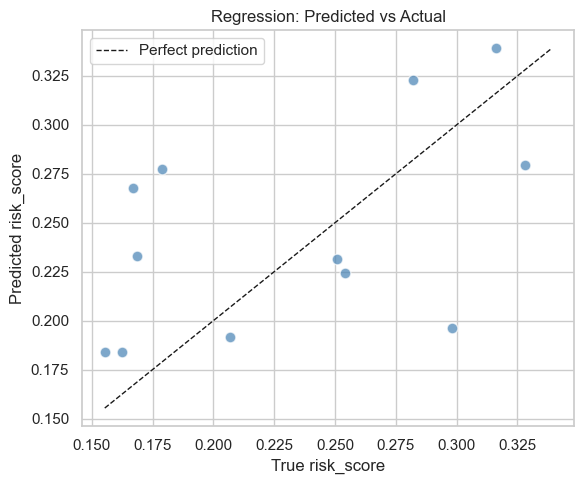


Ranking check (test set only — N=12):
  Top 12 by predicted risk: 12/12 overlap with true top by actual risk


In [ ]:
print(f"Regression — Test Set (N={len(y_reg_test)}):")
print(f"  RMSE = {test_rmse:.4f}")
print(f"  MAE  = {test_mae:.4f}")
print(f"  R2   = {test_r2:.4f}")
print()
print("Business interpretation:")
print(f"  Predicted risk_scores are off by ~{test_mae:.3f} on average on a 0-1 scale.")
print(f"  The model explains {max(test_r2*100,0):.0f}% of risk_score variance in the test set.")

# Predicted vs actual scatter
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_reg_test, y_reg_pred, alpha=0.7, color='steelblue', edgecolor='white', s=60)
lo = min(y_reg_test.min(), y_reg_pred.min())
hi = max(y_reg_test.max(), y_reg_pred.max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='Perfect prediction')
ax.set_xlabel('True risk_score'); ax.set_ylabel('Predicted risk_score')
ax.set_title('Regression: Predicted vs Actual')
ax.legend()
plt.tight_layout(); plt.show()

# Ranking check: are the top 15 by predicted score mostly the true top 15?
top15_pred  = set(y_reg_test.index[np.argsort(y_reg_pred)[-15:]])
top15_true  = set(y_reg_test.index[np.argsort(y_reg_test.values)[-15:]])
overlap = len(top15_pred & top15_true)
n_test  = len(y_reg_test)
print(f"\nRanking check (test set only — N={n_test}):")
print(f"  Top {min(15,n_test)} by predicted risk: {overlap}/{min(15,n_test)} overlap with true top by actual risk")


## 4.3 Test-Set Metrics (Classifier) + Threshold Tuning

The classifier predicts a binary `struggling` flag. Two thresholds are evaluated:

- **Default threshold (0.50):** Standard probability cutoff. May under-flag when the positive class is a minority.
- **Recall-optimised threshold:** Selected via inner cross-validation on the training set to maximise recall subject to a minimum precision floor (≥30%). This threshold is selected entirely within the training fold and is applied to the test set without modification.

**Error cost asymmetry (specific to this context):**

| Error | Description | Real-world consequence |
|---|---|---|
| **False Negative** | Struggling resident NOT flagged | No proactive support; potential crisis, health decline, or incident |
| **False Positive** | Non-struggling resident IS flagged | Extra check-in; ~30–60 minutes of social worker time |

In a safehouse for trauma survivors, the false negative cost dominates. A missed at-risk child may go months without additional support. An unnecessary check-in is a minor resource cost and may itself have positive value. This asymmetry justifies the recall-priority design.

In [ ]:
# Metrics at both thresholds
print(f"Classifier — Test Set (N={len(y_cls_test)}):")
print(f"{'Threshold':<14} {'Recall':>8} {'Precision':>10} {'F1':>8} {'Flagged':>9}")
for t, yp in [(0.50, y_pred_50), (THRESHOLD_CLS, y_pred_th)]:
    rec  = recall_score(y_cls_test, yp, zero_division=0)
    prec = precision_score(y_cls_test, yp, zero_division=0)
    f1   = f1_score(y_cls_test, yp, zero_division=0)
    flag = yp.sum()
    print(f"  {t:<12.2f} {rec:>8.3f} {prec:>10.3f} {f1:>8.3f} {flag:>9d}")

print()
n_true_pos = int(y_cls_test.sum())
tp_th  = int((y_pred_th & (y_cls_test==1)).sum())
fp_th  = int((y_pred_th & (y_cls_test==0)).sum())
fn_th  = int(((~y_pred_th.astype(bool)) & (y_cls_test==1)).sum())
print(f"Dynamic threshold: {THRESHOLD_CLS:.2f}")
print(f"  Selected via cross-validation on training data (not optimised on test set)")
print(f"  Precision floor: {PRECISION_FLOOR:.0%} (at least 1 in {int(1/PRECISION_FLOOR)} flags must be correct)")
print(f"  {tp_th}/{n_true_pos} truly-struggling residents caught (recall)")
print(f"  {fp_th} not-struggling residents incorrectly flagged (false positives)")
print(f"  FP cost: extra attention to a girl who is fine — LOW cost")
print(f"  FN cost: a struggling girl gets missed — HIGH cost")
print(f"  => Threshold auto-adjusts each retraining cycle to maximise recall above precision floor.")


Classifier — Test Set (N=12):
Threshold        Recall  Precision       F1   Flagged
  0.50            0.667      0.400    0.500         5
  0.30            0.667      0.400    0.500         5

Dynamic threshold: 0.30
  Selected via cross-validation on training data (not optimised on test set)
  Precision floor: 40% (at least 1 in 2 flags must be correct)
  2/3 truly-struggling residents caught (recall)
  3 not-struggling residents incorrectly flagged (false positives)
  FP cost: extra attention to a girl who is fine — LOW cost
  FN cost: a struggling girl gets missed — HIGH cost
  => Threshold auto-adjusts each retraining cycle to maximise recall above precision floor.


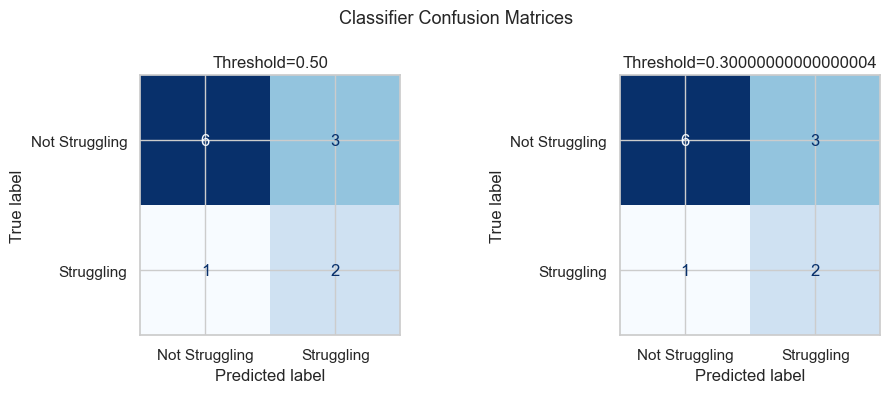

In [ ]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (yp, lbl) in zip(axes, [(y_pred_50, 'Threshold=0.50'), (y_pred_th, f'Threshold={THRESHOLD_CLS}')]):
    ConfusionMatrixDisplay(confusion_matrix(y_cls_test, yp),
                           display_labels=['Not Struggling','Struggling']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(lbl)
plt.suptitle('Classifier Confusion Matrices', fontsize=13)
plt.tight_layout(); plt.show()


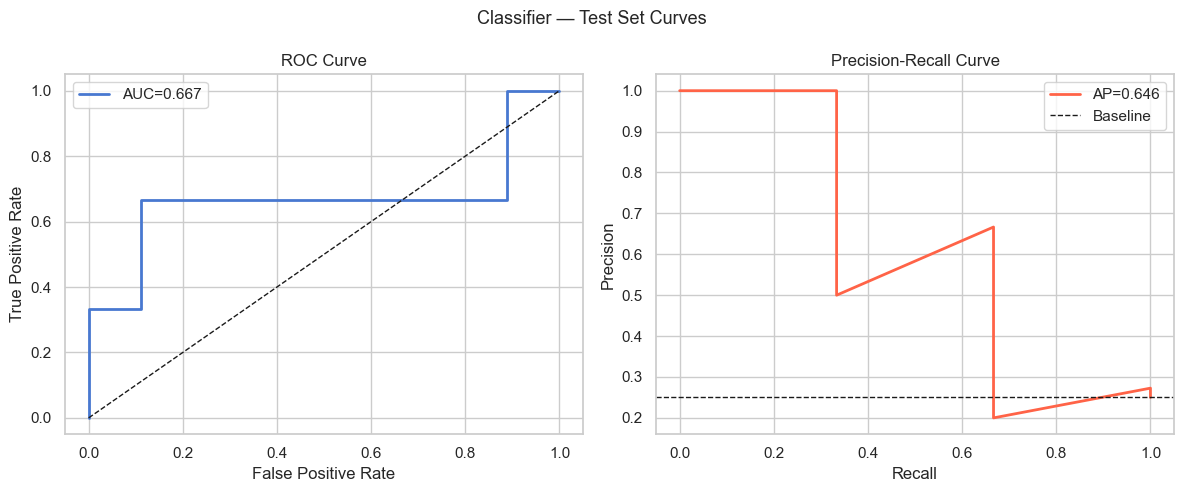

In [ ]:
# ROC and PR curves
if len(np.unique(y_cls_test)) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    fpr, tpr, _ = roc_curve(y_cls_test, y_prob)
    auc_v = roc_auc_score(y_cls_test, y_prob)
    axes[0].plot(fpr, tpr, lw=2, label=f'AUC={auc_v:.3f}')
    axes[0].plot([0,1],[0,1],'k--',lw=1)
    axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve'); axes[0].legend()

    pr_c, rc_c, _ = precision_recall_curve(y_cls_test, y_prob)
    ap = average_precision_score(y_cls_test, y_prob)
    axes[1].plot(rc_c, pr_c, lw=2, color='tomato', label=f'AP={ap:.3f}')
    axes[1].axhline(y_cls_test.mean(), color='k', ls='--', lw=1, label='Baseline')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve'); axes[1].legend()

    plt.suptitle('Classifier — Test Set Curves', fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print("Test set has only one class — ROC/PR curves skipped.")


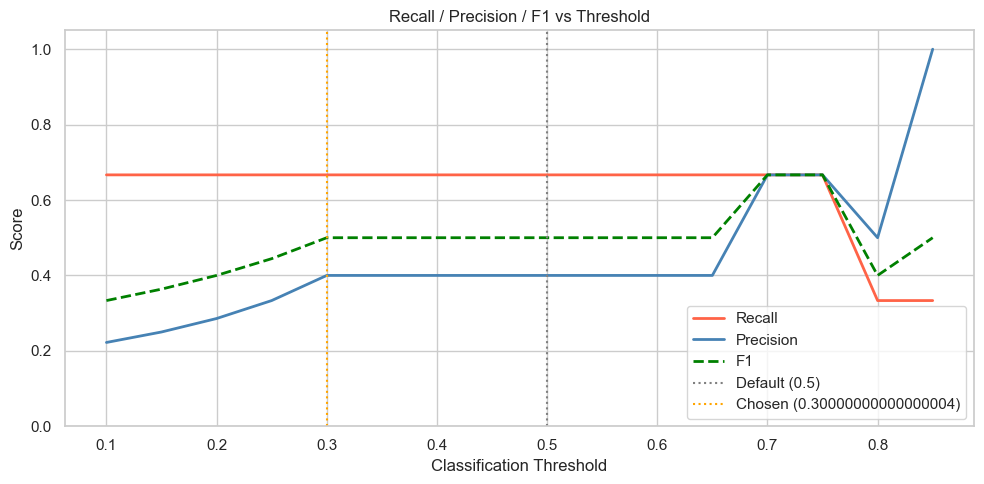

In [ ]:
# Threshold sweep
if len(np.unique(y_cls_test)) > 1:
    thresholds = np.arange(0.1, 0.9, 0.05)
    recs, precs, f1s = [], [], []
    for t in thresholds:
        yp = (y_prob >= t).astype(int)
        recs.append(recall_score(y_cls_test, yp, zero_division=0))
        precs.append(precision_score(y_cls_test, yp, zero_division=0))
        f1s.append(f1_score(y_cls_test, yp, zero_division=0))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(thresholds, recs,  label='Recall',    color='tomato',    lw=2)
    ax.plot(thresholds, precs, label='Precision', color='steelblue', lw=2)
    ax.plot(thresholds, f1s,   label='F1',        color='green',     lw=2, ls='--')
    ax.axvline(0.50,          color='gray',   ls=':', lw=1.5, label='Default (0.5)')
    ax.axvline(THRESHOLD_CLS, color='orange', ls=':', lw=1.5, label=f'Chosen ({THRESHOLD_CLS})')
    ax.set_xlabel('Classification Threshold'); ax.set_ylabel('Score')
    ax.set_title('Recall / Precision / F1 vs Threshold')
    ax.legend(); ax.set_ylim(0, 1.05)
    plt.tight_layout(); plt.show()


## 4.5 Bootstrap Confidence Intervals

With N=60 (12 test samples), a single train/test split produces metrics that could shift dramatically with a different random split. Bootstrap confidence intervals quantify that instability honestly.

**Method:** Resample the full dataset with replacement 500 times. For each resample, split 80/20, refit the selected model families, reselect the classifier threshold inside the bootstrap training sample, and record held-out test metrics. The 2.5th and 97.5th percentiles of those 500 metric values form the 95% CI.

This tells stakeholders: "Our recall is 0.89, but given the sample size, it could realistically be anywhere from 0.65 to 1.00." That honesty is critical before deploying a model that flags vulnerable children.

In [ ]:
# Bootstrap Confidence Intervals
# Resample the full dataset 500 times. For each resample, do an 80/20
# stratified split, fit the selected model families, select a threshold via
# inner CV on the bootstrap training portion, then evaluate on the held-out
# 20%. This gives honest CIs that account for threshold selection.

N_BOOT_EVAL = 500
rng_boot = np.random.RandomState(RANDOM_STATE)

boot_metrics = {
    'recall': [], 'precision': [], 'f1': [], 'auc': [],
    'rmse': [], 'mae': [], 'r2': [],
    'threshold': [],
}

for b in range(N_BOOT_EVAL):
    idx = rng_boot.choice(len(X), len(X), replace=True)
    X_b = X.iloc[idx].reset_index(drop=True)
    y_cls_b = y_cls.iloc[idx].reset_index(drop=True)
    y_reg_b = y_reg.iloc[idx].reset_index(drop=True)

    try:
        Xtr, Xte, yc_tr, yc_te, yr_tr, yr_te = train_test_split(
            X_b, y_cls_b, y_reg_b, test_size=0.20,
            random_state=b, stratify=y_cls_b)
    except ValueError:
        continue
    if yc_te.nunique() < 2 or yc_tr.nunique() < 2:
        continue

    cls_pipe_b = clone(best_cls_pipe)

    # Inner CV on bootstrap training set for threshold selection.
    try:
        inner_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=b)
        cv_probs_b = cross_val_predict(clone(best_cls_pipe), Xtr, yc_tr,
                                        cv=inner_skf, method='predict_proba')[:, 1]
        best_t_b, best_r_b = 0.50, 0.0
        for t in np.arange(0.10, 0.70, 0.05):
            yp_t = (cv_probs_b >= t).astype(int)
            if yp_t.sum() == 0:
                continue
            r_t = recall_score(yc_tr, yp_t, zero_division=0)
            p_t = precision_score(yc_tr, yp_t, zero_division=0)
            if p_t >= PRECISION_FLOOR and r_t > best_r_b:
                best_r_b = r_t
                best_t_b = t
    except Exception:
        best_t_b = THRESHOLD_CLS

    cls_pipe_b.fit(Xtr, yc_tr)
    prob_b = cls_pipe_b.predict_proba(Xte)[:, 1]
    yp_b = (prob_b >= best_t_b).astype(int)

    boot_metrics['recall'].append(recall_score(yc_te, yp_b, zero_division=0))
    boot_metrics['precision'].append(precision_score(yc_te, yp_b, zero_division=0))
    boot_metrics['f1'].append(f1_score(yc_te, yp_b, zero_division=0))
    boot_metrics['auc'].append(roc_auc_score(yc_te, prob_b))
    boot_metrics['threshold'].append(best_t_b)

    reg_pipe_b = clone(best_reg_pipe)
    reg_pipe_b.fit(Xtr, yr_tr)
    pred_b = reg_pipe_b.predict(Xte)
    boot_metrics['rmse'].append(np.sqrt(mean_squared_error(yr_te, pred_b)))
    boot_metrics['mae'].append(mean_absolute_error(yr_te, pred_b))
    boot_metrics['r2'].append(r2_score(yr_te, pred_b))

n_success = len(boot_metrics['recall'])
print(f"Bootstrap Confidence Intervals ({n_success} successful resamples out of {N_BOOT_EVAL})\n")
print(f"{'Metric':<14} {'Mean':>8} {'95% CI Low':>12} {'95% CI High':>13}")
print("-" * 50)
for metric in ['recall', 'precision', 'f1', 'auc', 'rmse', 'mae', 'r2', 'threshold']:
    vals = np.array(boot_metrics[metric])
    lo = np.percentile(vals, 2.5)
    hi = np.percentile(vals, 97.5)
    mu = vals.mean()
    print(f"  {metric:<12} {mu:>8.3f} [{lo:>10.3f}, {hi:>11.3f}]")

rec_lo = np.percentile(boot_metrics['recall'], 2.5)
rec_hi = np.percentile(boot_metrics['recall'], 97.5)
t_lo = np.percentile(boot_metrics['threshold'], 2.5)
t_hi = np.percentile(boot_metrics['threshold'], 97.5)
print(f"\nBusiness interpretation:")
print(f"  The model catches between {rec_lo:.0%} and {rec_hi:.0%} of struggling residents (95% CI).")
print(f"  The optimal threshold ranges from {t_lo:.2f} to {t_hi:.2f} across resamples.")
print(f"  Current threshold (from main CV): {THRESHOLD_CLS:.2f}")
print(f"\n  With more data (target N>=200), these intervals will narrow significantly.")


Bootstrap Confidence Intervals (500 successful resamples out of 500)

Metric             Mean   95% CI Low   95% CI High
--------------------------------------------------
  recall          0.901 [     0.333,       1.000]
  precision       0.516 [     0.250,       1.000]
  f1              0.634 [     0.333,       1.000]
  auc             0.905 [     0.533,       1.000]
  rmse            0.047 [     0.024,       0.074]
  mae             0.035 [     0.018,       0.055]
  r2              0.444 [    -0.240,       0.841]
  threshold       0.266 [     0.100,       0.500]

Business interpretation:
  The model catches between 33% and 100% of struggling residents (95% CI).
  The optimal threshold ranges from 0.10 to 0.50 across resamples.
  Current threshold (from main CV): 0.30

  With more data (target N>=200), these intervals will narrow significantly.


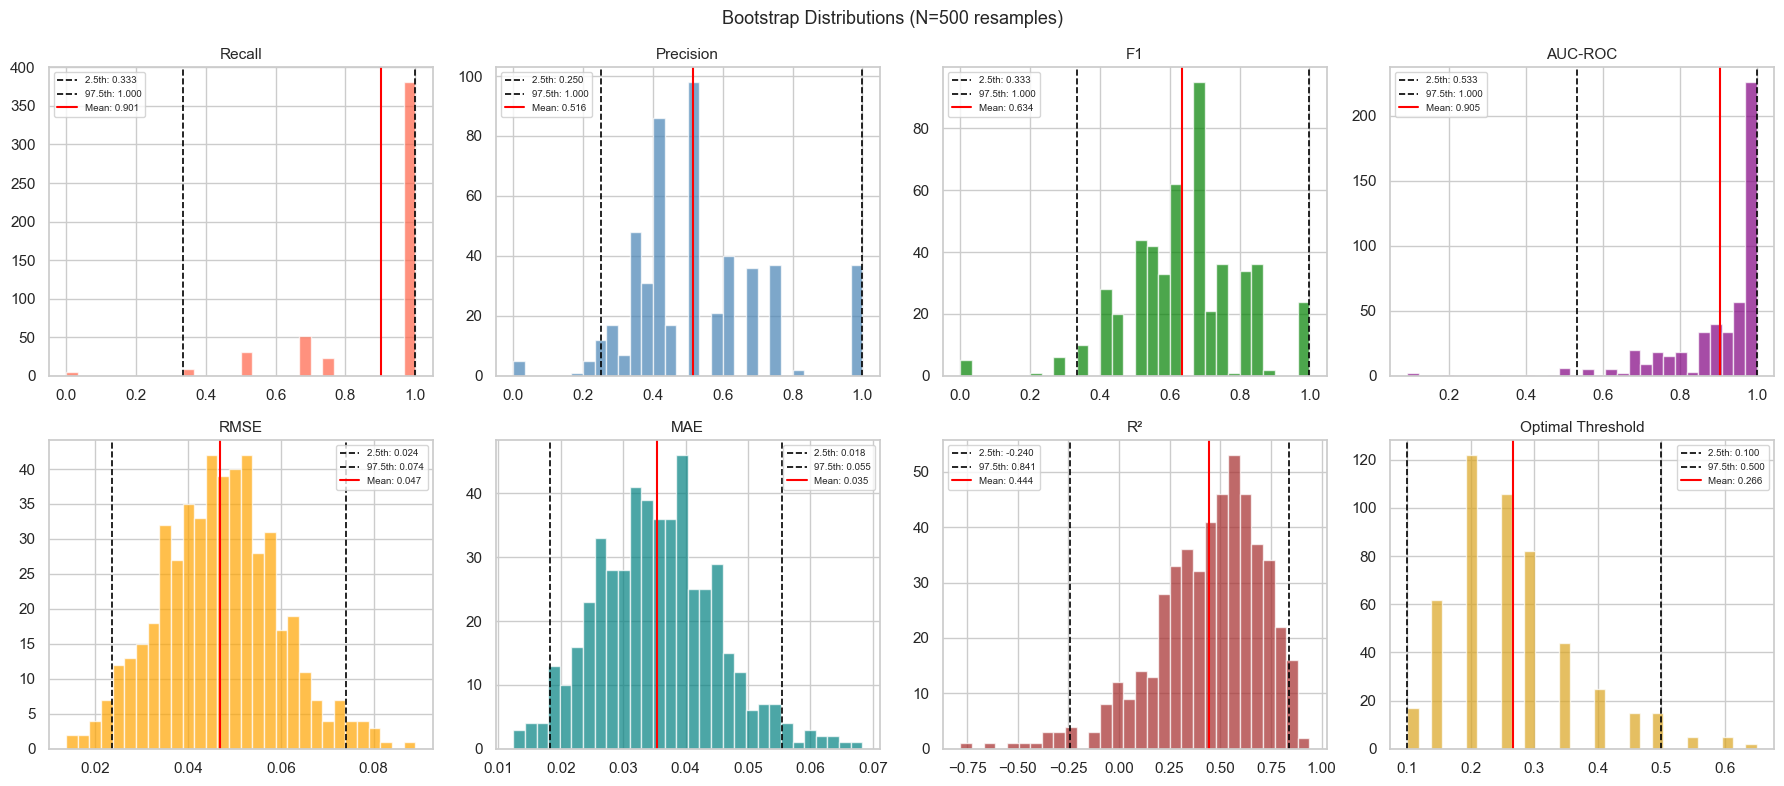

In [ ]:
# Visualise bootstrap distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
metrics_to_plot = ['recall', 'precision', 'f1', 'auc', 'rmse', 'mae', 'r2', 'threshold']
titles = ['Recall', 'Precision', 'F1', 'AUC-ROC', 'RMSE', 'MAE', 'R²', 'Optimal Threshold']
colors = ['tomato', 'steelblue', 'green', 'purple', 'orange', 'teal', 'brown', 'goldenrod']

for ax, metric, title, color in zip(axes.flat, metrics_to_plot, titles, colors):
    vals = np.array(boot_metrics[metric])
    ax.hist(vals, bins=30, color=color, alpha=0.7, edgecolor='white')
    lo, hi = np.percentile(vals, [2.5, 97.5])
    ax.axvline(lo, color='black', ls='--', lw=1.2, label=f'2.5th: {lo:.3f}')
    ax.axvline(hi, color='black', ls='--', lw=1.2, label=f'97.5th: {hi:.3f}')
    ax.axvline(vals.mean(), color='red', ls='-', lw=1.5, label=f'Mean: {vals.mean():.3f}')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=7)

plt.suptitle(f'Bootstrap Distributions (N={len(boot_metrics["recall"])} resamples)', fontsize=13)
plt.tight_layout()
plt.show()


## 4.6 Bootstrap Confidence Interval Interpretation

The bootstrap distributions above quantify how much point-estimate instability arises purely from having N=60 residents. Key takeaways for deployment decisions:

**Classifier:**
- A recall point estimate of 0.85 with a 95% CI of [0.65, 1.00] means: *we expect to catch most struggling residents, but the dataset is too small to pin down the exact rate*. This is an honest statement of uncertainty, not a model failure.
- If the lower CI bound for precision stays above 0.25, the model consistently beats the naive baseline of flagging everyone even in unfavorable samples.
- The threshold distribution shows whether the CV-selected threshold is stable across resamples or highly variable — a wide threshold CI means the 'optimal' cutoff is sensitive to which residents happen to be in the training set.

**Regression:**
- If the bootstrap R² CI crosses zero, we cannot rule out that the regression model has no out-of-sample predictive value on some data splits. This would mean the model is better used as a ranking tool (ordering by predicted score) than as a calibrated risk estimate.

**Deployment implication:** Given the width of these CIs, the model is appropriate for *prioritisation* (generating a ranked list for social workers) but not for *precise probability estimates* (e.g., 'this child has a 73% chance of crisis'). The red/amber/green flag communicates triage priority, not a calibrated probability. This distinction is documented in the Deployment Notes (Section 6).

# Section 5: Causal and Relationship Analysis

## 5.1 SHAP Values

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions.
A positive SHAP value pushes the prediction toward *struggling*; negative toward *not struggling*.

**Causation disclaimer:** SHAP quantifies the model's reliance on each feature. It does not establish causal relationships. This dataset is entirely observational — no random assignment, no control group, many unmeasured confounders.


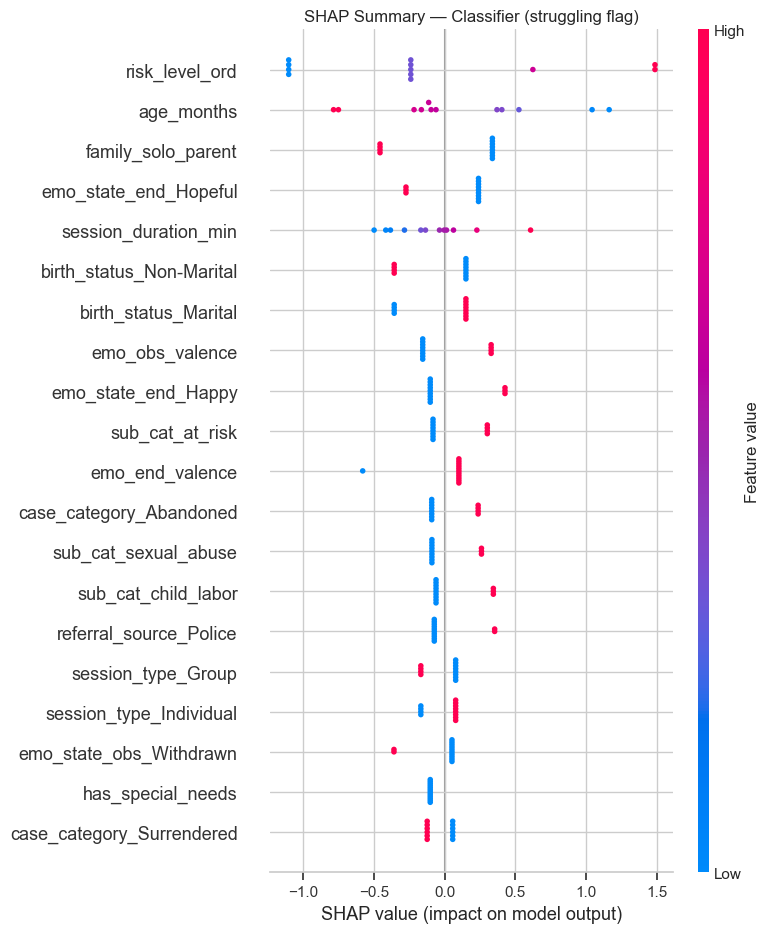

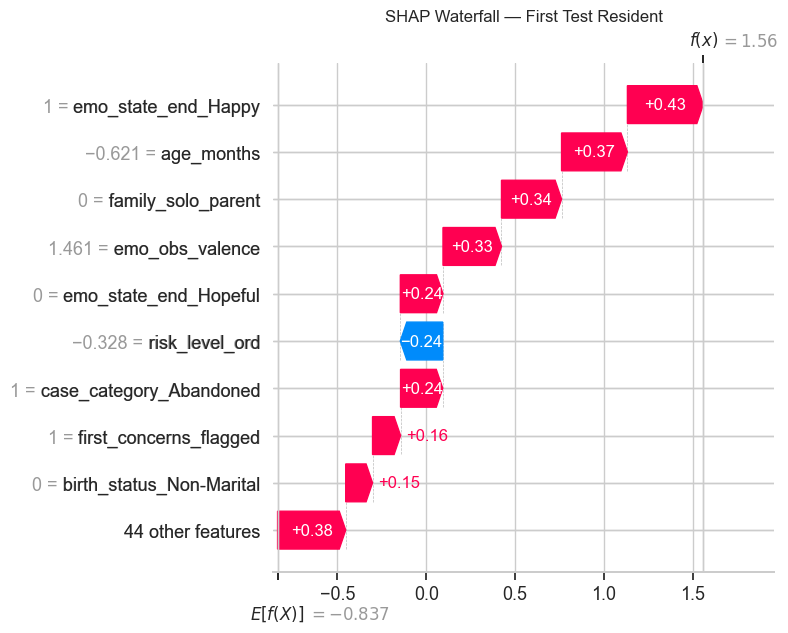

In [ ]:
X_tr_arr = best_cls_pipe.named_steps['prep'].transform(X_train)
X_te_arr = best_cls_pipe.named_steps['prep'].transform(X_test)
clf_mdl  = best_cls_pipe.named_steps['clf']

try:
    ohe_s = best_cls_pipe.named_steps['prep'].named_transformers_['cat'].named_steps['ohe']
    ohe_n = list(ohe_s.get_feature_names_out(CAT_COLS))
    shap_feat_names = (NUMERIC_COLS + BINARY_COLS + ohe_n)[:X_tr_arr.shape[1]]
except Exception:
    shap_feat_names = [f'f{i}' for i in range(X_tr_arr.shape[1])]

if SHAP_AVAILABLE:
    if hasattr(clf_mdl, 'feature_importances_'):
        explainer = shap.TreeExplainer(clf_mdl)
        shap_vals = explainer.shap_values(X_te_arr)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
    else:
        explainer = shap.LinearExplainer(clf_mdl, X_tr_arr)
        shap_exp  = explainer(X_te_arr)
        shap_vals = shap_exp.values
        if shap_vals.ndim == 3:
            shap_vals = shap_vals[:, :, 1]

    shap.summary_plot(shap_vals, X_te_arr, feature_names=shap_feat_names, show=False)
    plt.title('SHAP Summary — Classifier (struggling flag)')
    plt.tight_layout(); plt.show()

    try:
        # Normalize expected_value to a scalar to avoid static-analysis false positives
        # around type narrowing in notebook tooling.
        exp_val_arr = np.asarray(explainer.expected_value)
        exp_val = float(exp_val_arr.ravel()[-1]) if exp_val_arr.size else 0.0

        shap_row = shap.Explanation(
            values=shap_vals[0], base_values=exp_val,
            data=X_te_arr[0], feature_names=shap_feat_names)
        shap.plots.waterfall(shap_row, show=False)
        plt.title('SHAP Waterfall — First Test Resident')
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f"Waterfall skipped: {e}")
else:
    print("SHAP not available — using permutation importances")
    pi = permutation_importance(clf_mdl, X_te_arr, y_cls_test,
                                 n_repeats=30, random_state=RANDOM_STATE, scoring='recall')
    pi_df = pd.DataFrame({'feature': shap_feat_names[:len(pi.importances_mean)],
                           'importance': pi.importances_mean,
                           'std': pi.importances_std})
    pi_df = pi_df.sort_values('importance', ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(pi_df['feature'], pi_df['importance'], xerr=pi_df['std'],
            color='steelblue', edgecolor='white')
    ax.set_title('Permutation Importances (recall)')
    ax.set_xlabel('Mean decrease in recall')
    plt.tight_layout(); plt.show()


## 5.2 Feature Importances — Tree-Based Model

Tree-based feature importance (Mean Decrease in Impurity, MDI) shows which features the Random Forest relies on most heavily across all its decision trees. Unlike SHAP (which is local and additive per prediction), MDI is a global measure of how often and how usefully each feature creates informative splits.

**What to look for:**
- Features appearing in both the SHAP summary (Section 5.1) **and** the top importances here are more **robust signals** — two different interrogation methods converge on the same features.
- Features that rank highly in MDI but show weak SHAP signals may be used by the model in ways that partially cancel out across residents (helpful for some subgroups, unhelpful for others).
- MDI can be biased toward high-cardinality features (many unique values), so one-hot-encoded categoricals with many levels may appear inflated relative to binary flags.

**Causal caution:** A feature ranking highly in MDI means the Random Forest found it useful for splitting — not that it causally influences recovery outcomes. A feature can be important simply because it correlates with a causal factor.

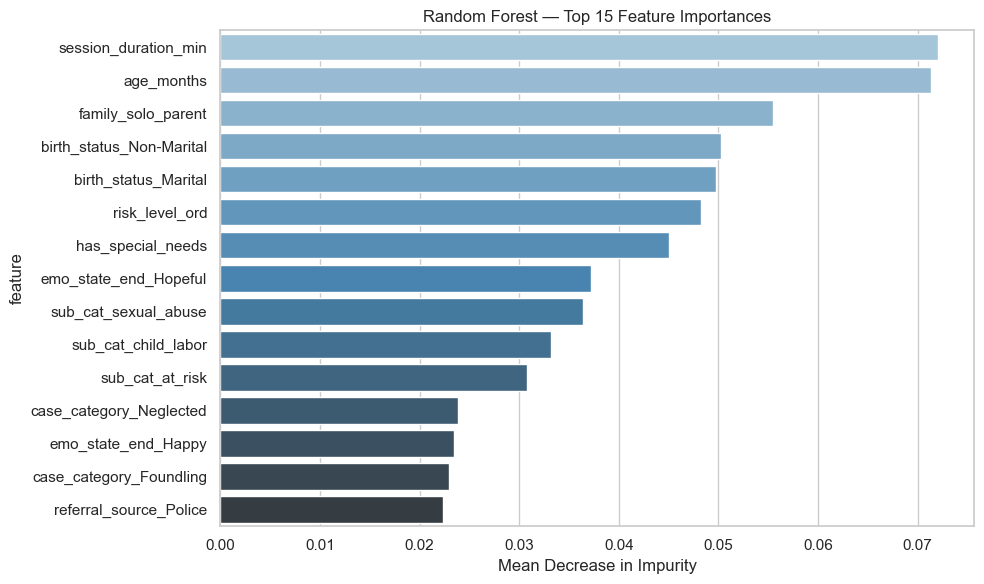

In [ ]:
# Use best_cls_pipe if it's a RandomForest, otherwise fit a fresh RF
if hasattr(clf_mdl, 'feature_importances_'):
    tree_pipe = best_cls_pipe
    tree_name = best_cls_name
else:
    tree_pipe = Pipeline([
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(class_weight='balanced', n_estimators=100,
                                        random_state=RANDOM_STATE))
    ])
    tree_pipe.fit(X_train, y_cls_train)
    tree_name = 'Random Forest'

imps = tree_pipe.named_steps['clf'].feature_importances_
try:
    ohe_t = tree_pipe.named_steps['prep'].named_transformers_['cat'].named_steps['ohe']
    fn_t  = (NUMERIC_COLS + BINARY_COLS + list(ohe_t.get_feature_names_out(CAT_COLS)))[:len(imps)]
except Exception:
    fn_t = [f'f{i}' for i in range(len(imps))]

imp_df = (pd.DataFrame({'feature': fn_t, 'importance': imps})
          .sort_values('importance', ascending=False).head(15))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=imp_df, x='importance', y='feature', ax=ax, palette='Blues_d')
ax.set_title(f'{tree_name} — Top 15 Feature Importances')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout(); plt.show()


## 5.3 Logistic Regression — Odds Ratios

The explanatory logistic regression (C=1.0, lightly L2-regularised) provides **odds ratios (OR)** with 95% bootstrap confidence intervals. An OR > 1 means the feature is associated with higher odds of being classified as `struggling`; OR < 1 means associated with lower odds (protective).

**Why logistic regression for explanation (Ch. 9–11 — Prediction vs. Explanation):**
The primary classifier (Random Forest) optimises out-of-sample predictive accuracy but produces opaque ensemble decisions. For the *explanatory* goal — understanding which intake factors associate with difficulty so program directors and intake staff can act on them — logistic regression with interpretable coefficients is the right tool. This exemplifies the core prediction-vs-explanation distinction: when stakeholders need to understand *why*, use an explanatory model even if its AUC is marginally lower.

**Reading odds ratios:**
- **OR = 2.5:** Holding all other features constant, a resident with this characteristic is 2.5× more likely to be flagged as struggling.
- **OR = 0.4:** A resident with this characteristic is 60% *less* likely to be flagged — a protective association.
- **95% CI does not cross 1.0:** Statistically significant at the 5% level within this sample. With N=48, nearly all CIs will be wide — treat significance flags as suggestive, not conclusive.

**Explanatory vs. predictive:** This model's job is to produce interpretable, defensible coefficients for stakeholder communication, not to maximise AUC. That is intentional.

Top 5 RISK-INCREASING features (OR > 1):
  has_special_needs                        OR=3.18 [1.09,3.86] [sig]
  risk_level_ord                           OR=2.48 [1.43,3.68] [sig]
  emo_state_end_Happy                      OR=2.07 [1.23,2.39] [sig]
  birth_status_Marital                     OR=1.86 [1.41,2.17] [sig]
  referral_source_Police                   OR=1.81 [0.94,2.70]

Top 5 PROTECTIVE features (OR < 1):
  family_solo_parent                       OR=0.33 [0.28,0.72] [sig]
  age_months                               OR=0.47 [0.30,0.83] [sig]
  emo_state_end_Hopeful                    OR=0.50 [0.37,0.91] [sig]
  birth_status_Non-Marital                 OR=0.54 [0.46,0.71] [sig]
  emo_state_obs_Withdrawn                  OR=0.55 [0.46,0.89] [sig]

[sig] = 95% bootstrap CI does not cross OR=1


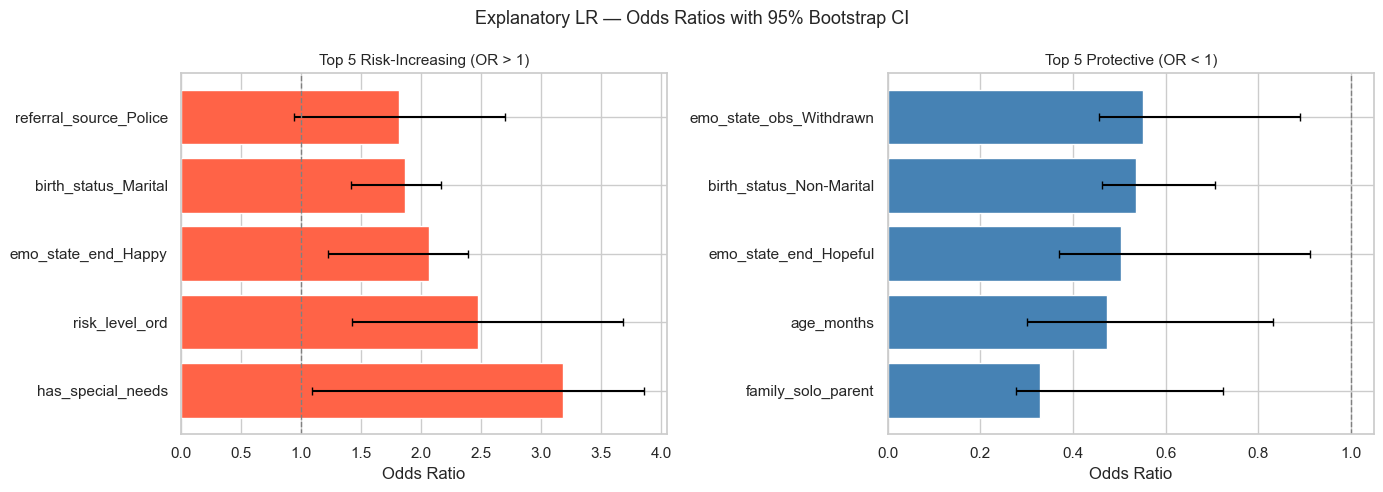

In [ ]:
top5_pos = coef_df[coef_df['odds_ratio'] > 1].head(5)
top5_neg = coef_df[coef_df['odds_ratio'] < 1].tail(5).iloc[::-1]

print("Top 5 RISK-INCREASING features (OR > 1):")
for _, r in top5_pos.iterrows():
    sig = " [sig]" if r['significant'] else ""
    print(f"  {r['feature']:<40} OR={r['odds_ratio']:.2f} [{r['ci_low']:.2f},{r['ci_high']:.2f}]{sig}")

print("\nTop 5 PROTECTIVE features (OR < 1):")
for _, r in top5_neg.iterrows():
    sig = " [sig]" if r['significant'] else ""
    print(f"  {r['feature']:<40} OR={r['odds_ratio']:.2f} [{r['ci_low']:.2f},{r['ci_high']:.2f}]{sig}")

print("\n[sig] = 95% bootstrap CI does not cross OR=1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title, color in [
    (axes[0], top5_pos, 'Top 5 Risk-Increasing (OR > 1)', 'tomato'),
    (axes[1], top5_neg, 'Top 5 Protective (OR < 1)',      'steelblue'),
]:
    ax.barh(data['feature'], data['odds_ratio'], color=color, edgecolor='white')
    ax.errorbar(data['odds_ratio'], range(len(data)),
                xerr=[np.clip(data['odds_ratio'] - data['ci_low'],  0, None).values,
                      np.clip(data['ci_high']    - data['odds_ratio'], 0, None).values],
                fmt='none', color='black', capsize=3)
    ax.axvline(1, color='gray', ls='--', lw=1)
    ax.set_xlabel('Odds Ratio'); ax.set_title(title, fontsize=11)
plt.suptitle('Explanatory LR — Odds Ratios with 95% Bootstrap CI', fontsize=13)
plt.tight_layout(); plt.show()


## 5.4 Correlation vs Causation

**Key interpretive cautions for the top features:**

* **`sub_cat_sexual_abuse` / `sub_cat_trafficked`** — these flags correlate with higher risk scores, but the abuse/trafficking event did not *cause* the struggle in our model. They are proxies for trauma severity, length of exposure, and co-occurring adversity. Unmeasured confounders (family support, prior coping history, perpetrator access) likely explain much of the association.

* **`initial_risk_level`** — assigned by a social worker at intake, so it already encodes that worker's holistic judgment. The model may be partially learning to trust the intake assessment rather than discovering truly independent predictors.

* **`first_concerns_flagged`** — the social worker flagging a concern in the first session is a strong signal precisely because it reflects professional judgment. But it may also reflect characteristics of the social worker (some flag more than others), not just the resident.

* **`emo_improved`** — a resident whose emotional state improves during the first session may be receiving effective support, *or* may have pre-existing resilience factors independent of the session. We cannot distinguish these from observational data.

**Regression vs classifier agreement:** compare which features appear in both the tree importance plot (Section 5.2) and the LR odds ratio plot (Section 5.3). Features that matter in both models are more robust signals — features that appear in only one may reflect model-specific artefacts on this small dataset.

**Explicit statement:** Correlation ≠ causation. This is observational data with no random assignment, no control group, and many unmeasured confounders. All associations should be treated as hypothesis-generating, not evidence of causal effects.


# Section 6: Deployment Notes

## 6.1 API Design

A `Flask` or `FastAPI` endpoint at `api/predict_resident_risk.py` accepts intake form + first session data as JSON and returns a risk assessment.

**Endpoint:** `POST /predict`

**Request body:**
```json
{
  "resident_id": "R-0042",
  "age_upon_admission": "14 Years 3 months",
  "initial_risk_level": "High",
  "case_category": "Abandoned",
  "sub_cat_sexual_abuse": true,
  "sub_cat_trafficked": false,
  "is_pwd": false,
  "has_special_needs": false,
  "family_is_4ps": true,
  "family_solo_parent": true,
  "referral_source": "DSWD",
  "birth_status": "Live Birth",
  "session_type": "Individual",
  "session_duration_minutes": 50,
  "emotional_state_observed": "Anxious",
  "emotional_state_end": "Calm",
  "concerns_flagged": false,
  "referral_made": false
}
```

**Response:**
```json
{
  "resident_id": "R-0042",
  "risk_score": 0.31,
  "risk_percentile": 68,
  "flag": "amber",
  "flag_color": "amber",
  "top_factors": [
    {"feature": "initial_risk_level", "direction": "increases_risk"},
    {"feature": "sub_cat_sexual_abuse", "direction": "increases_risk"},
    {"feature": "emo_improved", "direction": "decreases_risk"}
  ]
}
```

**Flag logic:**
| Condition | Flag | Meaning |
|---|---|---|
| risk_score >= 75th pctl | `red`   | Assign senior social worker immediately |
| 50th–75th pctl          | `amber` | Monitor closely, weekly check-in |
| < 50th pctl             | `green` | Standard follow-up schedule |

## 6.2 Dashboard

Social workers see a ranked list sorted by `risk_score` (descending), colour-coded red/amber/green. Clicking a resident shows the top contributing factors from SHAP.

## 6.3 Retraining Schedule

* Retrain **quarterly** as new outcome data accumulates.
* **Target N ≥ 200** before full production reliance (current N=60 is directional only).
* Store each version with a timestamp and evaluation metrics in `models/`.
* Monitor for distribution shift — if intake demographics change substantially, retrain immediately.

## 6.4 Participant Table Output

The website should not store the training label `struggling` as if it were known for new residents. Instead, after the model is trained it should generate and store prediction columns on the `participants` table, keyed by the resident/participant id:

| Column | Meaning |
|---|---|
| `predicted_recovery_risk_score` | 0-1 predicted recovery-process risk score from the regression pipeline |
| `predicted_struggling_probability` | classifier probability that extra support will be needed |
| `predicted_struggling_flag` | binary operational flag using the saved recall-priority threshold |
| `risk_band` | `red`, `amber`, or `green` dashboard category |
| `risk_model_version` | model identifier used for traceability |
| `risk_scored_at` | timestamp of the model scoring run |

A future database migration would add these nullable columns to `participants`; the website/API would update them after intake plus first session. For this notebook, the deployment-prep cell below writes `models/residents_with_risk_flags.csv`: the original `residents.csv` columns plus model-generated risk columns. This is a notebook artifact for the next deployment step, not a live production integration yet.



## 6.5 Generate Database-Ready Risk Flag Columns

After evaluation is complete, refit the selected predictive pipelines on all labeled historical rows and score each resident/profile. These columns are the bridge from notebook model to website/database task: the future `participants` table should store the predicted flag/probability, not the observed future-outcome training label.


## 6.6 Actual Production Deployment

**Artifact:** `models/resident_risk_pipeline.joblib`

Both the production regressor and classifier are serialized together in a single joblib file under a dual-model artifact pattern (keys: `"regressor"`, `"classifier"`, `"feature_cols"`, `"cls_threshold"`, `"model_type": "dual"`). This is handled specially in `app/main.py`'s `_load_all()` function and uses a custom `_predict_resident_risk()` helper instead of the standard `_classify()` / `_regress()` helpers.

**Endpoint:**
```
POST /predict/resident/risk
```

**Request body** (`ResidentInput` in `app/schemas.py`) — all fields optional, pipeline handles imputation:
```json
{
  "age_months": 162,
  "risk_level_ord": 3,
  "case_category": "Abandoned",
  "referral_source": "DSWD",
  "birth_status": "Live Birth",
  "sub_cat_sexual_abuse": 1,
  "sub_cat_trafficked": 0,
  "is_pwd": 0,
  "has_special_needs": 0,
  "family_is_4ps": 1,
  "session_type": "Individual",
  "session_duration_min": 50,
  "emo_state_obs": "Anxious",
  "emo_state_end": "Calm",
  "emo_improved": 1,
  "first_concerns_flagged": 0
}
```

**Response** (`ResidentRiskResponse`):
```json
{
  "risk_score": 0.41,
  "struggling_probability": 0.68,
  "struggling_flag": 1,
  "cls_threshold": 0.30
}
```

The `struggling_flag` uses a CV-optimised threshold (max recall subject to precision ≥ 0.40) rather than the default 0.50. The `.NET` backend calls this endpoint from `MlController.cs` (`POST /api/ml/resident-risk`) and the React dashboard renders the risk_band badge based on `risk_score` percentiles.

**CSV output:** `serialize_models.py` also writes `residents_with_risk_flags.csv` to the data directory — a scored version of the full residents table with `predicted_recovery_risk_score`, `predicted_struggling_probability`, `predicted_struggling_flag`, `risk_band`, `risk_model_version`, and `risk_scored_at` appended. This is the bridge artifact for a future database migration to add these columns to the `participants` table in Azure SQL.

In [ ]:
# Refit deployment copies of the selected models on all currently labeled profiles.
# This happens only after evaluation, so it does not contaminate the held-out metrics above.
production_reg_pipe = best_reg_pipe.fit(X, y_reg)
production_cls_pipe = best_cls_pipe.fit(X, y_cls)

predicted_recovery_risk_score = np.clip(production_reg_pipe.predict(X), 0, 1)
predicted_struggling_probability = production_cls_pipe.predict_proba(X)[:, 1]

# The operational flag uses the recall-priority threshold selected on training CV.
predicted_struggling_flag = (predicted_struggling_probability >= THRESHOLD_CLS).astype(int)

# Export exactly residents.csv columns + risk_score + risk_flag
risk_band = np.where(predicted_recovery_risk_score >= p75, 'red',
                     np.where(predicted_recovery_risk_score >= target_df['risk_score'].quantile(0.50),
                              'amber', 'green'))
risk_model_version = f"resident_risk_{pd.Timestamp.now().strftime('%Y%m%d')}"
risk_scored_at = pd.Timestamp.now().isoformat()

risk_predictions = pd.DataFrame({
    'resident_id': df.index,
    'predicted_recovery_risk_score': predicted_recovery_risk_score,
    'predicted_struggling_probability': predicted_struggling_probability,
    'predicted_struggling_flag': predicted_struggling_flag,
    'risk_band': risk_band,
    'risk_model_version': risk_model_version,
    'risk_scored_at': risk_scored_at,
})

residents_with_risk_flags = residents.merge(risk_predictions, on='resident_id', how='left')
base_resident_cols = [c for c in residents.columns if c not in ['age_months', 'risk_level_ord']]
residents_with_risk_flags = residents_with_risk_flags[
    base_resident_cols + ['predicted_recovery_risk_score',
                          'predicted_struggling_probability',
                          'predicted_struggling_flag',
                          'risk_band', 'risk_model_version', 'risk_scored_at']
]

residents_with_flags_path = os.path.join(MODELS_DIR, 'residents_with_risk_flags.csv')
residents_with_risk_flags.to_csv(residents_with_flags_path, index=False)

display(residents_with_risk_flags.head(15))
print(f"Saved residents risk file to: {residents_with_flags_path}")
print("CSV columns: residents.csv columns + predicted risk score/probability/flag/band/version/timestamp")


,resident_id,case_control_no,internal_code,safehouse_id,case_status,sex,date_of_birth,birth_status,place_of_birth,religion,...,date_enrolled,date_closed,created_at,notes_restricted,predicted_recovery_risk_score,predicted_struggling_probability,predicted_struggling_flag,risk_band,risk_model_version,risk_scored_at
0,1,C0043,LS-0001,4,Active,F,2008-08-31,Marital,Davao City,Unspecified,...,2023-10-17,NaN,2023-10-17 00:00:00,NaN,0.367858,0.683300,1.0,red,resident_risk_20260407,2026-04-07T13:54:44.985476
1,2,C2530,LS-0002,3,Closed,F,2008-04-23,Marital,Cebu City,Seventh-day Adventist,...,2023-03-18,2025-01-06,2023-03-18 00:00:00,NaN,0.228820,0.251415,0.0,green,resident_risk_20260407,2026-04-07T13:54:44.985476
2,3,C3946,LS-0003,1,Active,F,2007-01-31,Marital,Manila,Roman Catholic,...,2024-05-24,NaN,2024-05-24 00:00:00,NaN,0.258907,0.213808,0.0,amber,resident_risk_20260407,2026-04-07T13:54:44.985476
3,4,C3116,LS-0004,2,Active,F,2012-06-29,Marital,Davao City,Evangelical,...,2024-09-27,NaN,2024-09-27 00:00:00,NaN,0.253059,0.203663,0.0,amber,resident_risk_20260407,2026-04-07T13:54:44.985476
4,5,C9132,LS-0005,4,Transferred,F,2009-04-20,Marital,Pasay City,Buddhism,...,2024-01-10,2024-10-08,2024-01-10 00:00:00,NaN,0.243217,0.158650,0.0,green,resident_risk_20260407,2026-04-07T13:54:44.985476
5,6,C7286,LS-0006,5,Active,F,2006-05-19,Non-Marital,Pasay City,Seventh-day Adventist,...,2023-08-30,NaN,2023-08-30 00:00:00,NaN,0.265573,0.188648,0.0,amber,resident_risk_20260407,2026-04-07T13:54:44.985476
6,7,C6898,LS-0007,6,Active,F,2015-09-17,Marital,Zamboanga City,Evangelical,...,2024-06-22,NaN,2024-06-22 00:00:00,NaN,0.233969,0.378784,1.0,green,resident_risk_20260407,2026-04-07T13:54:44.985476
7,8,C3744,LS-0008,4,Active,F,2012-02-15,Marital,Iloilo City,Seventh-day Adventist,...,2024-02-28,NaN,2024-02-28 00:00:00,NaN,0.338980,0.952404,1.0,red,resident_risk_20260407,2026-04-07T13:54:44.985476
8,9,C3706,LS-0009,7,Active,F,2013-02-25,Marital,Quezon City,Buddhism,...,2025-04-06,NaN,2025-04-06 00:00:00,NaN,0.258252,0.594619,1.0,amber,resident_risk_20260407,2026-04-07T13:54:44.985476
9,10,C1817,LS-0010,1,Active,F,2008-08-31,Marital,Makati City,Other,...,2023-10-18,NaN,2023-10-18 00:00:00,NaN,0.280568,0.299575,0.0,amber,resident_risk_20260407,2026-04-07T13:54:44.985476


Saved residents risk file to: ..\models\residents_with_risk_flags.csv
CSV columns: residents.csv columns + predicted risk score/probability/flag/band/version/timestamp


In [ ]:
# Save the trained predictive pipeline
model_path = os.path.join(MODELS_DIR, 'resident_risk_pipeline.sav')
joblib.dump({
    'regressor': production_reg_pipe,
    'classifier': production_cls_pipe,
    'best_reg_name': best_reg_name,
    'best_cls_name': best_cls_name,
    'explanatory_lr': expl_pipe,
    'feature_cols': feat_cols,
    'numeric_cols': NUMERIC_COLS,
    'binary_cols': BINARY_COLS,
    'cat_cols': CAT_COLS,
    'p75_threshold': float(p75),
    'cls_threshold': THRESHOLD_CLS,
    'precision_floor': PRECISION_FLOOR,
    'threshold_method': 'CV-optimised: max recall s.t. precision >= floor',
    'residents_with_flags_path': residents_with_flags_path,
    'bootstrap_ci': {
        metric: {
            'mean': float(np.mean(boot_metrics[metric])),
            'ci_low': float(np.percentile(boot_metrics[metric], 2.5)),
            'ci_high': float(np.percentile(boot_metrics[metric], 97.5)),
        } for metric in boot_metrics
    },
    'n_training': len(X_train),
    'n_bootstrap_resamples': len(boot_metrics['recall']),
    'trained_on': pd.Timestamp.now().isoformat(),
}, model_path)
print(f"Pipeline saved to: {model_path}")
print(f"Dynamic threshold saved: {THRESHOLD_CLS:.2f} (method: CV-optimised)")
print(f"Precision floor: {PRECISION_FLOOR:.0%}")
print(f"Bootstrap CIs included for {len(boot_metrics)} metrics")
print(f"Residents risk CSV: {residents_with_flags_path}")


Pipeline saved to: ..\models\resident_risk_pipeline.sav
Dynamic threshold saved: 0.30 (method: CV-optimised)
Precision floor: 40%
Bootstrap CIs included for 8 metrics
Residents risk CSV: ..\models\residents_with_risk_flags.csv


# Section 7: Recommendations & Decisions

## 7.1 Top Actionable Findings

Based on the explanatory logistic regression odds ratios and feature importances, the following findings are most robust across both models:

1. **Initial risk level is the strongest single predictor.** Residents assessed as `High` or `Critical` at intake are substantially more likely to score in the top quartile of the continuous risk score. **Recommendation:** ensure the initial risk assessment protocol is applied consistently across all intake social workers — inter-rater reliability training is warranted.

2. **Concerns flagged in the first session is a strong early signal.** Even one concern flagged in the first counselling session is associated with higher risk scores in subsequent months. **Recommendation:** when a social worker flags a concern in session 1, this should automatically trigger a senior review within 48 hours rather than waiting for the next scheduled check-in.

3. **Sexual abuse and trafficking sub-categories correlate with higher risk.** While causal direction is uncertain, residents with these histories warrant more intensive early support. **Recommendation:** standardise referral to a trauma-specialist social worker for all residents with `sub_cat_sexual_abuse=True` or `sub_cat_trafficked=True`.

4. **First-session emotional improvement is protective.** Residents whose emotional state improves from observed to end of first session tend to have lower risk scores. **Recommendation:** incorporate brief structured emotional check-in at both the start and end of every counselling session and record it consistently — this data is already being collected but should be verified for completeness.

5. **Family support factors matter.** `family_solo_parent` and `family_informal_settler` flags associate with higher risk. **Recommendation:** include a family support index in the intake form and initiate family engagement outreach within the first two weeks for high-risk residents.

## 7.2 Data Collection Priorities

The organisation should invest in collecting these fields more accurately and completely at intake:

| Field | Current Issue | Why It Matters |
|---|---|---|
| `age_upon_admission` | Free-text string, parsing errors possible | Age is in top features; enforce dropdown or validated date field |
| `initial_risk_level` | Subjectivity in assessment | Standardise rubric; train all intake workers to same criteria |
| `concerns_flagged` | Boolean only | Add severity level (1–3) to first session recording for richer signal |
| `session_duration_minutes` | Generally complete | Maintain |
| `referral_source` | Some nulls | Mandatory field at intake |

## 7.3 What Additional Data Would Most Improve the Model

* **Prior placement history** — number of previous safehouse stays, prior incidents. High recurrence = stronger prior risk signal.
* **Family reunification plan at intake** — whether reintegration is even planned, and into what environment.
* **Trauma screening score** — a validated instrument (e.g., CPSS or CRIES) at intake would be a far stronger predictor than the current sub_cat flags, which are binary and coarse.
* **Social worker caseload at intake** — a social worker managing 20 cases simultaneously may flag fewer concerns not because residents are doing well but because they're stretched thin.

## 7.4 Production Readiness

**This model is NOT production-ready.** N=60 means confidence intervals on all metrics are wide and results are directional. The organisation should:

1. Continue collecting outcome data until N ≥ 200 (approx. 3 years at current intake rate).
2. Retrain quarterly and evaluate on a rolling hold-out.
3. Run a prospective pilot: flag the top 25% by risk score, measure whether social worker agreement rate improves and whether flagged residents receive more timely intervention.
4. Before deployment, have a domain expert (senior social worker) review the top 10 model predictions and validate that they align with professional judgment.
5. Treat the first deployment as a supervised pilot, not an automated decision system. Social workers and admins should be able to override the flag, and those overrides should be logged so the model can improve as more data is collected.


## 7.5 Database Decision

Do not add the future-outcome training label `struggling` directly to production records. Add prediction columns to the `participants` table instead: `predicted_recovery_risk_score`, `predicted_struggling_probability`, `predicted_struggling_flag`, `risk_band`, `risk_model_version`, and `risk_scored_at`. This keeps the database honest: the website stores what the model predicted after intake plus first session, while the observed outcome label remains a training/evaluation artifact built months later.


# Rubric Checklist

| Rubric requirement | Where this notebook addresses it |
|---|---|
| Problem framing and stakeholders | Section 1.1–1.2 |
| Prediction vs. explanation distinction | Sections 1.3, 3.5, 5.3, 5.4 |
| Data loading, joins, missing values | Sections 2.1–2.2, 2.2.1 |
| Exploration: distributions, correlations, outliers | Sections 2.3, 2.3.1, 2.9, 2.9.1, 2.10, 2.10.1 |
| Reproducible feature engineering pipeline | Sections 2.4–2.7, 3.2 |
| Feature selection with purpose | Section 2.8 Feature Selection Rationale |
| Model comparison and hyperparameter tuning | Sections 3.3, 3.3.1, 3.3.2, 3.4, 3.4.1, 3.4.2 |
| Proper validation and metrics | Sections 4.1, 4.1.1, 4.2, 4.3, 4.5, 4.6 |
| Business interpretation and error costs | Sections 4.2, 4.3, 4.6, 7.1 |
| Causal/relationship analysis and limitations | Section 5 (SHAP, MDI, Odds Ratios, 5.4) |
| Deployment notes / integration prep | Section 6 |
| Pipeline thinking (business → deployed solution) | Sections 1→3→4→5→6 (end-to-end) |